# Sprint 3 — ResNet50 + Grad-CAM (André)

Notebook contribuído pelo integrante **André** (Sprint 3).

Pipeline: LIDC-IDRI → patches → **ResNet50** → Grad-CAM / testes de sanidade / Integrated Gradients.

**Paths locais deste repo**
- DICOM/XML: `data/LIDC-IDRI/`
- Artefatos do modelo: `models/resnet50/`
- Grad-CAM: `gradcam/resnet50/`
- Outputs intermediários: `outputs/sprint3/`

Originalmente desenvolvido no Kaggle; paths foram adaptados para este projeto.


**Imports**

In [2]:
import os
import time
from pathlib import Path
import copy
import random
import warnings
import numpy as np
import pandas as pd
import cv2
import pydicom
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from scipy.stats import pearsonr, spearmanr
from captum.attr import IntegratedGradients
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")


c:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Configurações Principais**

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# --- Paths do projeto (local) ---
_PROJECT_ROOT = Path("..").resolve()
if not (_PROJECT_ROOT / "data" / "LIDC-IDRI").exists():
    _PROJECT_ROOT = Path(".").resolve()

DICOM_PATH = _PROJECT_ROOT / "data" / "LIDC-IDRI"
# XMLs LidcReadMessage ficam dentro das pastas de paciente
XML_PATH = DICOM_PATH

MODEL_NAME = "resnet50"

NUM_CLASSES = 2

IMAGE_SIZE = 224

PATCH_SIZE = 96

BATCH_SIZE = 16

# Windows / Jupyter: manter 0
NUM_WORKERS = 0

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

EPOCHS = 10

OUTPUT_PATH = _PROJECT_ROOT / "outputs" / "sprint3"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_DIR = _PROJECT_ROOT / "models" / "resnet50"
GRADCAM_DIR = _PROJECT_ROOT / "gradcam" / "resnet50"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / "resnet50_sprint3_best.pth"

print("CONFIGURAÇÃO DA SPRINT 3 (local)")

print(f"PROJECT_ROOT: {_PROJECT_ROOT}")
print(f"DICOM:        {DICOM_PATH}")
print(f"XML:          {XML_PATH}")
print(f"Modelo:       {MODEL_NAME}")
print(f"Classes:      {NUM_CLASSES}")
print(f"Patch:        {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Input:        {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch size:   {BATCH_SIZE}")
print(f"Learning rate:{LEARNING_RATE}")
print(f"Épocas:       {EPOCHS}")
print(f"Output:       {OUTPUT_PATH}")
print(f"MODEL_DIR:    {MODEL_DIR}")
print(f"GRADCAM_DIR:  {GRADCAM_DIR}")
print(f"CHECKPOINT:   {CHECKPOINT_PATH}")


Device: cpu
CONFIGURAÇÃO DA SPRINT 3 (local)
PROJECT_ROOT: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03
DICOM:        C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI
XML:          C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI
Modelo:       resnet50
Classes:      2
Patch:        96x96
Input:        224x224
Batch size:   16
Learning rate:0.0001
Épocas:       10
Output:       C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\sprint3
MODEL_DIR:    C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\resnet50
GRADCAM_DIR:  C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\gradcam\resnet50
CHECKPOINT:   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\resnet50\resnet50_sprint3_best.pth


**Verificação do Dataset**

In [4]:
print("VERIFICAÇÃO DOS DATASETS")

print("\nDICOM:")
print("Existe:", DICOM_PATH.exists())

print("\nXML:")
print("Existe:", XML_PATH.exists())


patient_dirs = [
    p for p in DICOM_PATH.iterdir()
    if p.is_dir() and p.name.startswith("LIDC-IDRI")
]

print("\nNúmero de pacientes:", len(patient_dirs))


xml_files = list(XML_PATH.rglob("*.xml"))

print("Número de XMLs:", len(xml_files))


print("\nPrimeiros pacientes:")
for p in patient_dirs[:10]:
    print(" ", p.name)


print("\nPrimeiros XMLs:")
for x in xml_files[:5]:
    print(" ", x)

VERIFICAÇÃO DOS DATASETS

DICOM:
Existe: True

XML:
Existe: True

Número de pacientes: 75
Número de XMLs: 1417

Primeiros pacientes:
  LIDC-IDRI-0001
  LIDC-IDRI-0002
  LIDC-IDRI-0003
  LIDC-IDRI-0004
  LIDC-IDRI-0005
  LIDC-IDRI-0006
  LIDC-IDRI-0007
  LIDC-IDRI-0008
  LIDC-IDRI-0009
  LIDC-IDRI-0010

Primeiros XMLs:
  C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\_xml_official\161-resubmitted-correction-3-9-12.xml
  C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\_xml_official\tcia-lidc-xml\157\158.xml
  C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\_xml_official\tcia-lidc-xml\157\159.xml
  C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\_xml_official\tcia-lidc-xml\157\160.xml
  C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\_xml_official\tcia-lidc-xml\157\161.xml


**Indexação dos DICONs**

In [5]:
dicom_records = []

print("Indexando DICOMs...")

for patient_dir in patient_dirs:

    patient_id = patient_dir.name

    for dcm_path in patient_dir.rglob("*.dcm"):

        try:
            ds = pydicom.dcmread(
                dcm_path,
                stop_before_pixels=True
            )

            modality = getattr(ds, "Modality", None)

            if modality != "CT":
                continue

            dicom_records.append({
                "patient_id": patient_id,
                "study_uid": str(
                    getattr(ds, "StudyInstanceUID", "")
                ),
                "series_uid": str(
                    getattr(ds, "SeriesInstanceUID", "")
                ),
                "sop_uid": str(
                    getattr(ds, "SOPInstanceUID", "")
                ),
                "instance_number": int(
                    getattr(ds, "InstanceNumber", 0)
                ),
                "path": str(dcm_path)
            })

        except Exception:
            continue


dicom_index = pd.DataFrame(dicom_records)

print("INDEXAÇÃO CONCLUÍDA")

print("DICOMs CT:", len(dicom_index))
print(
    "Pacientes:",
    dicom_index["patient_id"].nunique()
)

print(
    "Studies:",
    dicom_index["study_uid"].nunique()
)

print(
    "Series:",
    dicom_index["series_uid"].nunique()
)

print(
    "SOPs:",
    dicom_index["sop_uid"].nunique()
)

Indexando DICOMs...
INDEXAÇÃO CONCLUÍDA
DICOMs CT: 7279
Pacientes: 42
Studies: 42
Series: 42
SOPs: 7279


**Salvar indice**

In [6]:
DICOM_INDEX_FILE = OUTPUT_PATH / "dicom_index.csv"

dicom_index.to_csv(
    DICOM_INDEX_FILE,
    index=False
)

print("Índice salvo em:")
print(DICOM_INDEX_FILE)

print(
    f"Tamanho: {DICOM_INDEX_FILE.stat().st_size / 1024**2:.2f} MB"
)

Índice salvo em:
C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\sprint3\dicom_index.csv
Tamanho: 2.71 MB


**PARSER DAS ANOTAÇÕES XML**

In [7]:
def local_tag(element):
    """
    Retorna o nome da tag ignorando namespace XML.
    """
    return element.tag.split("}")[-1]


def get_direct_child_text(element, tag_name, default=None):
    """
    Procura apenas entre os filhos diretos.
    """
    for child in element:
        if local_tag(child) == tag_name:
            if child.text is not None:
                return child.text.strip()

    return default


def parse_xml_annotations(xml_path):

    annotations = []

    try:

        tree = ET.parse(xml_path)
        root = tree.getroot()

        study_uid = None

        for element in root.iter():

            if local_tag(element) == "StudyInstanceUID":

                if element.text:
                    study_uid = element.text.strip()

                break


        reading_session_index = 0

        for reading_session in root.iter():

            if local_tag(reading_session) != "readingSession":
                continue

            reading_session_index += 1

            # Cada nódulo anotado pelo radiologista


            for nodule in reading_session:

                if local_tag(nodule) != "unblindedReadNodule":
                    continue
                    
                # ID do nódulo

                nodule_id = get_direct_child_text(
                    nodule,
                    "noduleID"
                )

   
                # Malignidade


                malignancy = None

                for element in nodule.iter():

                    if local_tag(element) == "malignancy":

                        if element.text:

                            try:
                                malignancy = int(
                                    float(element.text.strip())
                                )

                            except:
                                malignancy = None

                        break

                
                # ROIs
            
                roi_index = 0

                for roi in nodule:

                    if local_tag(roi) != "roi":
                        continue

                    roi_index += 1

                    # SOP da imagem
            

                    sop_uid = get_direct_child_text(
                        roi,
                        "imageSOP_UID"
                    )

                    # Z position
                

                    z_position = get_direct_child_text(
                        roi,
                        "imageZposition"
                    )

                    try:

                        z_position = float(
                            z_position
                        )

                    except:

                        z_position = None

                    # Extrair TODOS os pontos do ROI
                    
                    x_coords = []
                    y_coords = []

                    for element in roi.iter():

                        tag = local_tag(element)

                        if tag == "xCoord":

                            if element.text:

                                try:
                                    x_coords.append(
                                        int(float(
                                            element.text.strip()
                                        ))
                                    )
                                except:
                                    pass

                        elif tag == "yCoord":

                            if element.text:

                                try:
                                    y_coords.append(
                                        int(float(
                                            element.text.strip()
                                        ))
                                    )
                                except:
                                    pass

                 
                    # Formar pares X,Y
                  
                    points = list(
                        zip(
                            x_coords,
                            y_coords
                        )
                    )

                
                    # Salvar ROI
            
                    if sop_uid and len(points) >= 3:

                        annotations.append({

                            "xml_path": str(xml_path),

                            "study_uid": study_uid,

                            "sop_uid": sop_uid,

                            "nodule_id": nodule_id,

                            "malignancy": malignancy,

                            "reading_session": reading_session_index,

                            "roi_index": roi_index,

                            "z_position": z_position,

                            "points": points,

                            "num_points": len(points)
                        })

    except Exception as e:

        print(
            f"Erro ao processar XML: {xml_path}"
        )

        print(e)

    return annotations

**PROCESSAMENTO DE TODOS OS XMLs**

In [8]:
print("PROCESSANDO ANOTAÇÕES XML")

all_annotations = []

errors = []

for i, xml_path in enumerate(xml_files):

    try:

        annotations = parse_xml_annotations(
            xml_path
        )

        all_annotations.extend(
            annotations
        )

    except Exception as e:

        errors.append({
            "xml": str(xml_path),
            "error": str(e)
        })

    if (i + 1) % 100 == 0:

        print(
            f"Processados: {i + 1}/{len(xml_files)}"
        )


print("PROCESSAMENTO CONCLUÍDO")

print(
    f"XMLs encontrados: {len(xml_files):,}"
)

print(
    f"ROIs válidos: {len(all_annotations):,}"
)

print(
    f"Erros: {len(errors):,}"
)

PROCESSANDO ANOTAÇÕES XML
Processados: 100/1417
Processados: 200/1417
Processados: 300/1417
Processados: 400/1417
Processados: 500/1417
Processados: 600/1417
Processados: 700/1417
Processados: 800/1417
Processados: 900/1417
Processados: 1000/1417
Processados: 1100/1417
Processados: 1200/1417
Processados: 1300/1417
Processados: 1400/1417
PROCESSAMENTO CONCLUÍDO
XMLs encontrados: 1,417
ROIs válidos: 44,102
Erros: 0


**DATAFRAME DAS ANOTAÇÕES**

In [9]:
annotations_df = pd.DataFrame(
    all_annotations
)

print("RESUMO DAS ANOTAÇÕES")

print(
    f"Total de ROIs: {len(annotations_df):,}"
)

print(
    f"Studies: {annotations_df['study_uid'].nunique():,}"
)

print(
    f"SOPs: {annotations_df['sop_uid'].nunique():,}"
)

print(
    f"Nódulos: {annotations_df['nodule_id'].nunique():,}"
)

print(
    f"XMLs: {annotations_df['xml_path'].nunique():,}"
)

print("\nDistribuição de malignidade:")

display(
    annotations_df["malignancy"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nQuantidade de pontos por ROI:")

display(
    annotations_df["num_points"]
    .describe()
)

print("\nPrimeiras anotações:")

display(
    annotations_df[
        [
            "study_uid",
            "sop_uid",
            "nodule_id",
            "malignancy",
            "reading_session",
            "roi_index",
            "num_points"
        ]
    ].head(10)
)

RESUMO DAS ANOTAÇÕES
Total de ROIs: 44,102
Studies: 883
SOPs: 14,660
Nódulos: 4,206
XMLs: 949

Distribuição de malignidade:


malignancy
1.0     5472
2.0     8541
3.0    13890
4.0     7394
5.0     8798
NaN        7
Name: count, dtype: int64


Quantidade de pontos por ROI:


count    44102.000000
mean        41.883112
std         29.410591
min          3.000000
25%         22.000000
50%         32.000000
75%         54.000000
max        373.000000
Name: num_points, dtype: float64


Primeiras anotações:


,study_uid,sop_uid,nodule_id,malignancy,reading_session,roi_index,num_points
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100791367364...,12453,1.0,2,1,23
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,1.3.6.1.4.1.14519.5.2.1.6279.6001.150739457477...,12453,1.0,2,2,35
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100791367364...,2881,3.0,4,1,33
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,1.3.6.1.4.1.14519.5.2.1.6279.6001.150739457477...,2881,3.0,4,2,43
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.498089111228...,3,3.0,1,1,25
5,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.163230259801...,3,3.0,1,2,69
6,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.554419374464...,3,3.0,1,3,72
7,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.333090359302...,3,3.0,1,4,83
8,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.795216975697...,3,3.0,1,5,80
9,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.206828858093...,3,3.0,1,6,63


**ASSOCIAÇÃO XML → DICOM**

In [10]:
print("ASSOCIAÇÃO ENTRE XML E DICOM")


# Criar conjunto dos SOPs disponíveis
dicom_sops = set(
    dicom_index["sop_uid"]
)


# Verificar cada anotação
annotations_df["dicom_exists"] = (
    annotations_df["sop_uid"]
    .isin(dicom_sops)
)


total = len(annotations_df)

matched = annotations_df["dicom_exists"].sum()

not_matched = total - matched


print(f"Total de ROIs:             {total:,}")
print(f"ROIs com DICOM:            {matched:,}")
print(f"ROIs sem DICOM:            {not_matched:,}")


if total > 0:

    coverage = matched / total * 100

    print(
        f"Correspondência:          {coverage:.2f}%"
    )


print("\nDistribuição:")

display(
    annotations_df["dicom_exists"]
    .value_counts()
)

ASSOCIAÇÃO ENTRE XML E DICOM
Total de ROIs:             44,102
ROIs com DICOM:            2,755
ROIs sem DICOM:            41,347
Correspondência:          6.25%

Distribuição:


dicom_exists
False    41347
True      2755
Name: count, dtype: int64

**ASSOCIAR ANOTAÇÕES AOS DICOMs**

In [11]:
# Mapeia SOP Instance UID -> caminho do DICOM
sop_to_dicom = dict(
    zip(
        dicom_index["sop_uid"],
        dicom_index["path"]
    )
)

# Copia as anotações corrigidas
matched_annotations = annotations_df.copy()

# Associa cada ROI ao DICOM correspondente
matched_annotations["dicom_path"] = (
    matched_annotations["sop_uid"]
    .map(sop_to_dicom)
)

# Verifica correspondência
total_rois = len(matched_annotations)
rois_com_dicom = matched_annotations["dicom_path"].notna().sum()
rois_sem_dicom = matched_annotations["dicom_path"].isna().sum()

# Mantém apenas ROIs que possuem DICOM e malignidade válida
matched_annotations = matched_annotations[
    matched_annotations["dicom_path"].notna() &
    matched_annotations["malignancy"].notna()
].copy()

print("=" * 60)
print("ASSOCIAÇÃO XML → DICOM")
print("=" * 60)

print(f"Total de ROIs:          {total_rois:,}")
print(f"ROIs com DICOM:         {rois_com_dicom:,}")
print(f"ROIs sem DICOM:         {rois_sem_dicom:,}")

print(f"\nROIs válidas após filtro: {len(matched_annotations):,}")

print(
    f"Cobertura: "
    f"{rois_com_dicom / total_rois * 100:.2f}%"
)

print("\nExemplo:")
display(
    matched_annotations[
        [
            "study_uid",
            "sop_uid",
            "nodule_id",
            "malignancy",
            "reading_session",
            "num_points",
            "dicom_path"
        ]
    ].head()
)

ASSOCIAÇÃO XML → DICOM
Total de ROIs:          44,102
ROIs com DICOM:         2,755
ROIs sem DICOM:         41,347

ROIs válidas após filtro: 2,755
Cobertura: 6.25%

Exemplo:


,study_uid,sop_uid,nodule_id,malignancy,reading_session,num_points,dicom_path
561,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.397214514135...,Nodule 001,3.0,1,24,C:\Users\Administrator\Documents\Biopark\Proje...
562,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.230648696103...,Nodule 001,3.0,1,25,C:\Users\Administrator\Documents\Biopark\Proje...
563,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.814708737017...,Nodule 002,3.0,1,20,C:\Users\Administrator\Documents\Biopark\Proje...
564,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.311195925875...,Nodule 002,3.0,1,32,C:\Users\Administrator\Documents\Biopark\Proje...
565,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.217111089417...,Nodule 002,3.0,1,27,C:\Users\Administrator\Documents\Biopark\Proje...


**VISUALIZAÇÃO DE UMA ANOTAÇÃO REAL**

ROI selecionada:
Study UID:       1.3.6.1.4.1.14519.5.2.1.6279.6001.111578894836113526186151044207
SOP UID:         1.3.6.1.4.1.14519.5.2.1.6279.6001.210261661987033527714983590948
Nodule ID:       0
Malignidade:     4.0
Reading session: 4
Pontos:          215
DICOM:           C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\LIDC-IDRI-0023\1.3.6.1.4.1.14519.5.2.1.6279.6001.487745546557477250336016826588\00000036.dcm

Imagem: (512, 512)
Máscara: (512, 512)
Pixels positivos: 888


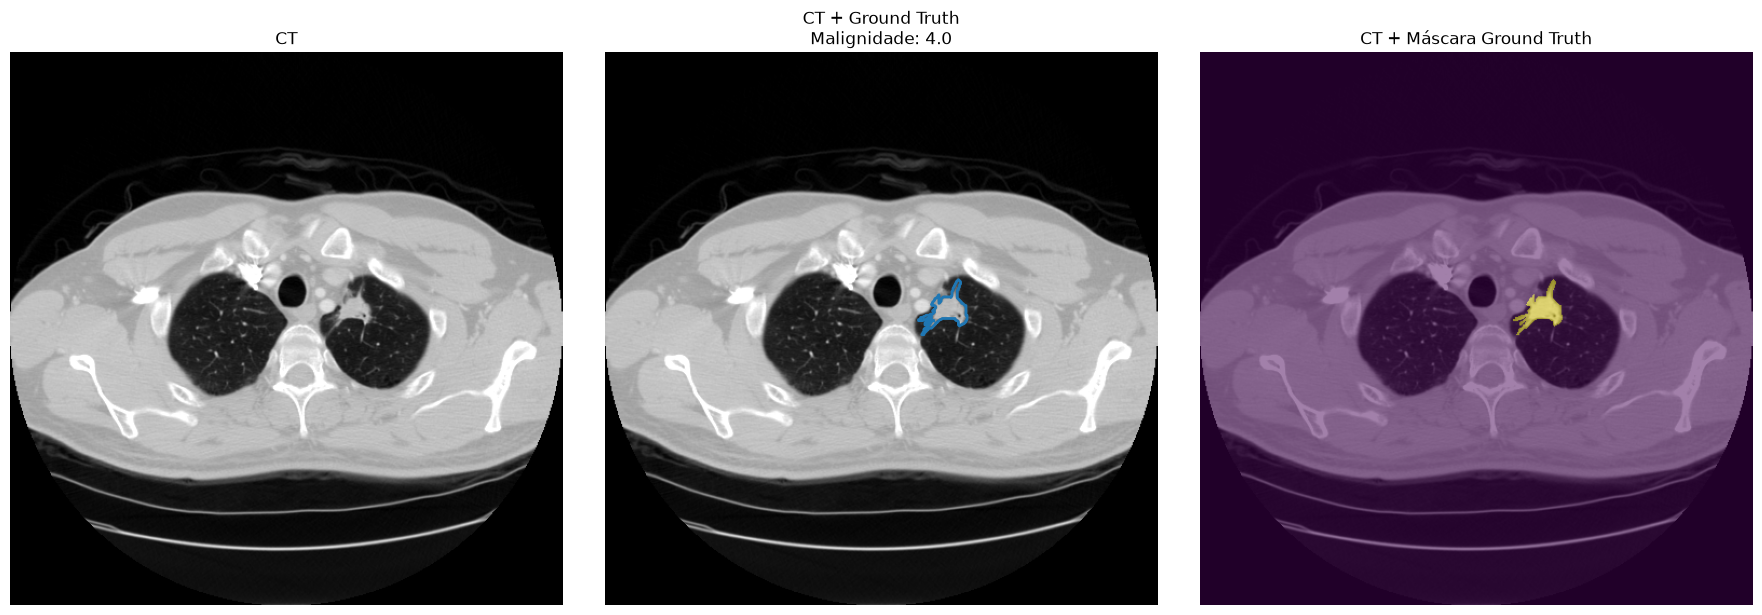

In [12]:
# Escolhe uma ROI com bastante pontos para facilitar a visualização
roi = matched_annotations.loc[
    matched_annotations["num_points"].idxmax()
]

print("ROI selecionada:")
print(f"Study UID:       {roi['study_uid']}")
print(f"SOP UID:         {roi['sop_uid']}")
print(f"Nodule ID:       {roi['nodule_id']}")
print(f"Malignidade:     {roi['malignancy']}")
print(f"Reading session: {roi['reading_session']}")
print(f"Pontos:          {roi['num_points']}")
print(f"DICOM:           {roi['dicom_path']}")

# Lê o DICOM

ds = pydicom.dcmread(roi["dicom_path"])

image = ds.pixel_array.astype(np.float32)

# Conversão para HU
slope = float(getattr(ds, "RescaleSlope", 1))
intercept = float(getattr(ds, "RescaleIntercept", 0))

image_hu = image * slope + intercept

# Window pulmonar
vmin = -1000
vmax = 400

image_window = np.clip(
    image_hu,
    vmin,
    vmax
)

# Normalização para visualização
image_norm = (
    (image_window - vmin) /
    (vmax - vmin)
)

# Recupera os pontos da ROI


points = roi["points"]

points = np.array(points, dtype=np.int32)

xs = points[:, 0]
ys = points[:, 1]


# Cria máscara binária

mask = np.zeros(
    image_norm.shape,
    dtype=np.uint8
)

cv2.fillPoly(
    mask,
    [points],
    1
)

print("\nImagem:", image_norm.shape)
print("Máscara:", mask.shape)
print("Pixels positivos:", mask.sum())

# Visualização

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagem original
axes[0].imshow(
    image_norm,
    cmap="gray"
)
axes[0].set_title("CT")

# Contorno
axes[1].imshow(
    image_norm,
    cmap="gray"
)

axes[1].plot(
    xs,
    ys,
    linewidth=2
)

axes[1].set_title(
    f"CT + Ground Truth\nMalignidade: {roi['malignancy']}"
)

# Máscara preenchida
axes[2].imshow(
    image_norm,
    cmap="gray"
)

axes[2].imshow(
    mask,
    alpha=0.5
)

axes[2].set_title(
    "CT + Máscara Ground Truth"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Extração dos patches + Ground Truth**

In [13]:
PATCH_SIZE = 224
MARGIN = 20

patches = []

def extract_patch_and_mask(row, patch_size=224, margin=20):
    """
    Lê um DICOM, cria a máscara Ground Truth a partir
    dos pontos da ROI e recorta imagem + máscara.
    """


    ds = pydicom.dcmread(row["dicom_path"])

    image = ds.pixel_array.astype(np.float32)

    # Conversão para HU
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))

    image_hu = image * slope + intercept


    mask = np.zeros(
        image_hu.shape,
        dtype=np.uint8
    )

    points = np.asarray(
        row["points"],
        dtype=np.int32
    )

    if len(points) < 3:
        return None

    # Garantir limites válidos
    h, w = image_hu.shape

    points[:, 0] = np.clip(points[:, 0], 0, w - 1)
    points[:, 1] = np.clip(points[:, 1], 0, h - 1)

    cv2.fillPoly(
        mask,
        [points],
        1
    )

    #Bounding box da máscara

    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x_min = max(0, xs.min() - margin)
    x_max = min(w, xs.max() + margin + 1)

    y_min = max(0, ys.min() - margin)
    y_max = min(h, ys.max() + margin + 1)

    # Recortar imagem e máscara

    image_patch = image_hu[
        y_min:y_max,
        x_min:x_max
    ]

    mask_patch = mask[
        y_min:y_max,
        x_min:x_max
    ]

    # Window pulmonar


    vmin = -1000
    vmax = 400

    image_patch = np.clip(
        image_patch,
        vmin,
        vmax
    )

    image_patch = (
        (image_patch - vmin) /
        (vmax - vmin)
    )

    #Resize

    image_patch = cv2.resize(
        image_patch,
        (patch_size, patch_size),
        interpolation=cv2.INTER_LINEAR
    )

    mask_patch = cv2.resize(
        mask_patch,
        (patch_size, patch_size),
        interpolation=cv2.INTER_NEAREST
    )

    # Garantir máscara binária
    mask_patch = (mask_patch > 0).astype(np.uint8)

    return {
        "image": image_patch.astype(np.float32),
        "mask": mask_patch,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max
    }



print("Processando ROIs...")

for idx, row in tqdm(
    matched_annotations.iterrows(),
    total=len(matched_annotations)
):

    try:

        result = extract_patch_and_mask(
            row,
            patch_size=PATCH_SIZE,
            margin=MARGIN
        )

        if result is None:
            continue

        patches.append({
            "annotation_index": idx,
            "study_uid": row["study_uid"],
            "sop_uid": row["sop_uid"],
            "nodule_id": row["nodule_id"],
            "malignancy": row["malignancy"],
            "reading_session": row["reading_session"],

            "image": result["image"],
            "mask": result["mask"],

            "x_min": result["x_min"],
            "x_max": result["x_max"],
            "y_min": result["y_min"],
            "y_max": result["y_max"]
        })

    except Exception as e:
        print(f"\nErro na ROI {idx}: {e}")


patches_df = pd.DataFrame(patches)

print("RESULTADO")

print(f"ROIs processadas: {len(matched_annotations):,}")
print(f"Patches criados:  {len(patches_df):,}")

print(
    f"\nTamanho das imagens: "
    f"{patches_df['image'].iloc[0].shape}"
)

print(
    f"Tamanho das máscaras: "
    f"{patches_df['mask'].iloc[0].shape}"
)

Processando ROIs...


100%|██████████| 2755/2755 [00:15<00:00, 174.20it/s]

RESULTADO
ROIs processadas: 2,755
Patches criados:  2,755

Tamanho das imagens: (224, 224)
Tamanho das máscaras: (224, 224)


**Verificação visual dos patches**

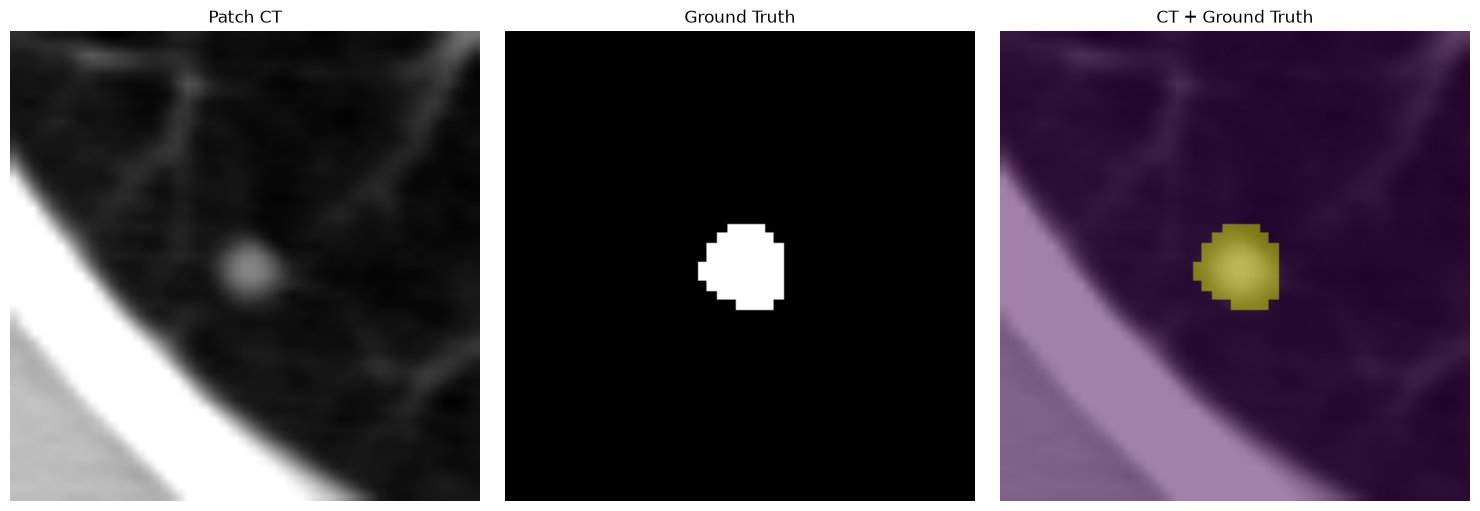

Malignidade: 3.0
Nodule ID: Nodule 001
Reading session: 1
Pixels positivos: 1312


In [14]:
sample = patches_df.iloc[0]

image_patch = sample["image"]
mask_patch = sample["mask"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    image_patch,
    cmap="gray"
)
axes[0].set_title("Patch CT")

axes[1].imshow(
    mask_patch,
    cmap="gray"
)
axes[1].set_title("Ground Truth")

axes[2].imshow(
    image_patch,
    cmap="gray"
)

axes[2].imshow(
    mask_patch,
    alpha=0.5
)

axes[2].set_title("CT + Ground Truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Malignidade:", sample["malignancy"])
print("Nodule ID:", sample["nodule_id"])
print("Reading session:", sample["reading_session"])
print("Pixels positivos:", int(mask_patch.sum()))

**Divisão por paciente**

In [17]:
# Criar mapa Study UID -> Patient ID

study_to_patient = (
    dicom_index[
        ["study_uid", "patient_id"]
    ]
    .drop_duplicates("study_uid")
    .set_index("study_uid")["patient_id"]
    .to_dict()
)

# Adiciona paciente aos patches
patches_df["patient_id"] = (
    patches_df["study_uid"].map(study_to_patient)
)

# Verificação
print("Patches sem paciente:",
      patches_df["patient_id"].isna().sum())

print("Pacientes encontrados:",
      patches_df["patient_id"].nunique())

#Remover possíveis registros sem paciente

patches_df = patches_df[
    patches_df["patient_id"].notna()
].copy()

# Criar label binário
#
# 1-2 = não grave
# 3-5 = grave

patches_df["label"] = (
    patches_df["malignancy"] >= 3
).astype(int)

#Obter pacientes únicos

patients = (
    patches_df[
        ["patient_id", "label"]
    ]
    .groupby("patient_id")["label"]
    .max()
    .reset_index()
)

print("\nTotal de pacientes:", len(patients))

print("\nDistribuição dos pacientes:")
print(
    patients["label"]
    .value_counts()
    .sort_index()
)

# Separar pacientes
#
# 70% treino
# 15% validação
# 15% teste
#
# stratify só é válido se cada classe tiver >= 2 membros no frame a dividir
# (subsets LIDC pequenos quebram o 2º split 50/50).

def _safe_train_test_split(frame, test_size, random_state, label_col="label"):
    counts = frame[label_col].value_counts()
    can_stratify = counts.min() >= 2 and counts.shape[0] >= 2
    if not can_stratify:
        print(
            "[warn] stratify desativado: contagem por classe insuficiente "
            f"({counts.to_dict()})"
        )
    return train_test_split(
        frame,
        test_size=test_size,
        random_state=random_state,
        stratify=frame[label_col] if can_stratify else None,
    )


train_patients, temp_patients = _safe_train_test_split(
    patients,
    test_size=0.30,
    random_state=42,
)

val_patients, test_patients = _safe_train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
)

#Criar conjuntos de pacientes

train_patient_ids = set(
    train_patients["patient_id"]
)

val_patient_ids = set(
    val_patients["patient_id"]
)

test_patient_ids = set(
    test_patients["patient_id"]
)

#Criar DataFrames

train_df = patches_df[
    patches_df["patient_id"].isin(train_patient_ids)
].copy()

val_df = patches_df[
    patches_df["patient_id"].isin(val_patient_ids)
].copy()

test_df = patches_df[
    patches_df["patient_id"].isin(test_patient_ids)
].copy()



print("DIVISÃO POR PACIENTE")
print(
    f"Treino:     {len(train_df):,} patches | "
    f"{train_df['patient_id'].nunique()} pacientes"
)

print(
    f"Validação:  {len(val_df):,} patches | "
    f"{val_df['patient_id'].nunique()} pacientes"
)

print(
    f"Teste:      {len(test_df):,} patches | "
    f"{test_df['patient_id'].nunique()} pacientes"
)

print("\nDistribuição das classes:")

print("\nTreino:")
print(train_df["label"].value_counts())

print("\nValidação:")
print(val_df["label"].value_counts())

print("\nTeste:")
print(test_df["label"].value_counts())

#Verificar vazamento de pacientes

train_val_overlap = (
    train_patient_ids & val_patient_ids
)

train_test_overlap = (
    train_patient_ids & test_patient_ids
)

val_test_overlap = (
    val_patient_ids & test_patient_ids
)

print("VERIFICAÇÃO DE DATA LEAKAGE")

print("Treino ∩ Validação:", len(train_val_overlap))
print("Treino ∩ Teste:    ", len(train_test_overlap))
print("Validação ∩ Teste: ", len(val_test_overlap))

Patches sem paciente: 0
Pacientes encontrados: 37

Total de pacientes: 37

Distribuição dos pacientes:
label
0     3
1    34
Name: count, dtype: int64
[warn] stratify desativado: contagem por classe insuficiente ({1: 11, 0: 1})
DIVISÃO POR PACIENTE
Treino:     1,592 patches | 25 pacientes
Validação:  565 patches | 6 pacientes
Teste:      598 patches | 6 pacientes

Distribuição das classes:

Treino:
label
1    1168
0     424
Name: count, dtype: int64

Validação:
label
1    468
0     97
Name: count, dtype: int64

Teste:
label
1    320
0    278
Name: count, dtype: int64
VERIFICAÇÃO DE DATA LEAKAGE
Treino ∩ Validação: 0
Treino ∩ Teste:     0
Validação ∩ Teste:  0


**Diagnóstico do balanceamento por paciente**

In [18]:
patient_distribution = (
    patches_df
    .groupby(["patient_id", "label"])
    .size()
    .unstack(fill_value=0)
)

# Garantir que as duas colunas existam
if 0 not in patient_distribution.columns:
    patient_distribution[0] = 0

if 1 not in patient_distribution.columns:
    patient_distribution[1] = 0

patient_distribution = patient_distribution[[0, 1]]

# Total de patches por paciente
patient_distribution["total"] = (
    patient_distribution[0] +
    patient_distribution[1]
)

# Porcentagem de classe 1
patient_distribution["pct_classe_1"] = (
    patient_distribution[1] /
    patient_distribution["total"] * 100
)

print("DISTRIBUIÇÃO DAS CLASSES POR PACIENTE")

print(
    patient_distribution.describe()
)

print("\nPacientes com apenas classe 0:")
print(
    ((patient_distribution[0] > 0) &
     (patient_distribution[1] == 0)).sum()
)

print("\nPacientes com apenas classe 1:")
print(
    ((patient_distribution[1] > 0) &
     (patient_distribution[0] == 0)).sum()
)

print("\nPacientes com as duas classes:")
print(
    ((patient_distribution[0] > 0) &
     (patient_distribution[1] > 0)).sum()
)

print("DISTRIBUIÇÃO ORIGINAL DOS PATCHES")

print(
    patches_df["label"]
    .value_counts()
    .sort_index()
)

print("\nPercentual:")

print(
    patches_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

DISTRIBUIÇÃO DAS CLASSES POR PACIENTE
label           0           1       total  pct_classe_1
count   37.000000   37.000000   37.000000     37.000000
mean    21.594595   52.864865   74.459459     68.134607
std     25.225053   47.016641   59.058631     29.019475
min      0.000000    0.000000    4.000000      0.000000
25%      6.000000   16.000000   30.000000     60.000000
50%     12.000000   42.000000   62.000000     71.590909
75%     32.000000   74.000000  112.000000     93.975904
max    128.000000  202.000000  256.000000    100.000000

Pacientes com apenas classe 0:
3

Pacientes com apenas classe 1:
9

Pacientes com as duas classes:
25
DISTRIBUIÇÃO ORIGINAL DOS PATCHES
label
0     799
1    1956
Name: count, dtype: int64

Percentual:
label
0    29.0
1    71.0
Name: proportion, dtype: float64


**Dataset e DataLoaders**

In [ ]:
class LIDCDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Imagem 224x224
        image = row["image"].astype(np.float32)

        # Garantir intervalo [0, 1]
        image = np.clip(image, 0, 1)

        # Grayscale -> 3 canais

        image = np.stack(
            [image, image, image],
            axis=0
        )

        # Normalização ImageNet

        mean = np.array(
            [0.485, 0.456, 0.406],
            dtype=np.float32
        ).reshape(3, 1, 1)

        std = np.array(
            [0.229, 0.224, 0.225],
            dtype=np.float32
        ).reshape(3, 1, 1)

        image = (image - mean) / std

        # Tensor
        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        # Label
        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return image, label


# Criar datasets

train_dataset = LIDCDataset(train_df)
val_dataset = LIDCDataset(val_df)
test_dataset = LIDCDataset(test_df)


# DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)



images, labels = next(iter(train_loader))

print("DATASET / DATALOADER")

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nBatch de imagens:")
print(images.shape)

print("\nBatch de labels:")
print(labels.shape)

print("\nLabels:")
print(labels[:10].tolist())

print("\nTipo:")
print(images.dtype)

**Pesos das classes**

In [ ]:
classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("PESOS DAS CLASSES")

print("Classe 0:", class_weights[0].item())
print("Classe 1:", class_weights[1].item())

print("\nDistribuição do treino:")
print(train_df["label"].value_counts().sort_index())

**ResNet50**

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

# ResNet50 pré-treinada

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Número de características da camada final
num_features = model.fc.in_features

# Classificação binária
model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print("\nModelo:")
print(model.fc)

**Loss e Otimizador**

In [ ]:
class_weights = class_weights.to(device)

# Loss ponderada
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Otimizador
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

**Funções de treinamento e validação**

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_preds = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Zerar gradientes
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Backward
        loss.backward()

        # Atualização
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        # Predição
        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

**Treinamento do ResNet50**

In [ ]:
EPOCHS = 10

history = []

best_f1 = 0.0
best_model_state = None

print("INICIANDO TREINAMENTO")

for epoch in range(EPOCHS):

    start_time = time.time()

    # Treino

    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validação

    val_metrics = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Scheduler

    scheduler.step(
        val_metrics["f1"]
    )

    # Salvar histórico

    history.append({
        "epoch": epoch + 1,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    # Melhor modelo

    if val_metrics["f1"] > best_f1:

        best_f1 = val_metrics["f1"]

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            CHECKPOINT_PATH
        )

        best_marker = " MELHOR"

    else:
        best_marker = ""

    # Tempo

    elapsed = time.time() - start_time

    print(
        f"\nÉpoca {epoch + 1}/{EPOCHS}"
        f" | {elapsed/60:.1f} min"
    )

    print(
        f"Train → "
        f"Loss: {train_metrics['loss']:.4f} | "
        f"Acc: {train_metrics['accuracy']:.4f} | "
        f"Prec: {train_metrics['precision']:.4f} | "
        f"Recall: {train_metrics['recall']:.4f} | "
        f"F1: {train_metrics['f1']:.4f}"
    )

    print(
        f"Val   → "
        f"Loss: {val_metrics['loss']:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f} | "
        f"Prec: {val_metrics['precision']:.4f} | "
        f"Recall: {val_metrics['recall']:.4f} | "
        f"F1: {val_metrics['f1']:.4f}"
        f"{best_marker}"
    )

    print(
        f"Learning Rate: "
        f"{optimizer.param_groups[0]['lr']:.2e}"
    )

if best_model_state is not None:
    model.load_state_dict(
        best_model_state
    )

print("TREINAMENTO FINALIZADO")

print(f"Melhor F1 de validação: {best_f1:.4f}")
print(
    "Checkpoint salvo em:",
    CHECKPOINT_PATH
)


**AVALIAÇÃO NO CONJUNTO DE TESTE**

In [ ]:
checkpoint_path = CHECKPOINT_PATH

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()

print("AVALIAÇÃO NO CONJUNTO DE TESTE")

print("\nModelo carregado:")
print(checkpoint_path)


# Realizar predições

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )

# Converter para arrays
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Métricas gerais

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)

print("MÉTRICAS GERAIS")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


print("MÉTRICAS POR CLASSE")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Classe 0",
            "Classe 1"
        ],
        zero_division=0
    )
)


cm = confusion_matrix(
    all_labels,
    all_preds
)

tn, fp, fn, tp = cm.ravel()

print("MATRIZ DE CONFUSÃO")

print(cm)

print("\nDetalhamento:")

print(f"Verdadeiros Negativos: {tn}")
print(f"Falsos Positivos:      {fp}")
print(f"Falsos Negativos:      {fn}")
print(f"Verdadeiros Positivos: {tp}")

# Visualização

fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Classe 0",
        "Classe 1"
    ]
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusão — ResNet50")
plt.show()

# Salvar resultados

test_results = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp
}

pd.DataFrame(
    [test_results]
).to_csv(
    (OUTPUT_PATH / "test_results_resnet50.csv"),
    index=False
)

print("\nResultados salvos em:")
print((OUTPUT_PATH / "test_results_resnet50.csv"))


**IMPLEMENTAÇÃO DO GRAD-CAM**

In [ ]:
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Hooks
        self.forward_handle = target_layer.register_forward_hook(
            self.save_activations
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, inputs, output):

        self.activations = output.detach()

    def save_gradients(self, module, grad_input, grad_output):

        self.gradients = grad_output[0].detach()

    def generate(self, image, target_class=None):

        self.model.zero_grad()

        # Forward
        output = self.model(image)

        # Se nenhuma classe for especificada,
        # usa a classe predita pelo modelo
        if target_class is None:

            target_class = torch.argmax(
                output,
                dim=1
            ).item()

        # Score da classe escolhida
        score = output[:, target_class]

        # Backward
        score.backward()

        # Activations:
        # [B, C, H, W]
        activations = self.activations

        # Gradients:
        # [B, C, H, W]
        gradients = self.gradients

        # Global Average Pooling dos gradientes
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Combinação ponderada das ativações
        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )

        # ReLU
        cam = F.relu(cam)

        # Remove dimensão do batch
        cam = cam.squeeze().cpu().numpy()

        # Normalização
        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return cam, target_class

    def remove_hooks(self):

        self.forward_handle.remove()
        self.backward_handle.remove()


# Criar Grad-CAM

target_layer = model.layer4[-1]

gradcam = GradCAM(
    model=model,
    target_layer=target_layer
)

print("Grad-CAM configurado.")
print(f"Target layer: {target_layer}")

**TESTE VISUAL DO GRAD-CAM**

In [ ]:
sample_idx = 0

sample_row = test_df.iloc[sample_idx]

# Imagem e máscara já estão armazenadas no DataFrame
image_np = np.asarray(
    sample_row["image"],
    dtype=np.float32
)

mask_np = np.asarray(
    sample_row["mask"],
    dtype=np.uint8
)

true_label = int(
    sample_row["label"]
)

# Preparar imagem para o modelo

image_tensor = torch.from_numpy(
    image_np
).float()

# [H,W] -> [1,1,H,W]
image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)

# Grayscale -> RGB
image_tensor = image_tensor.repeat(
    1, 3, 1, 1
)

# Normalização ImageNet
mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)

image_model = (
    image_tensor - mean
) / std

image_model = image_model.to(device)

# Gerar Grad-CAM

model.eval()

cam, predicted_class = gradcam.generate(
    image_model
)

# Redimensionar Grad-CAM

cam_resized = cv2.resize(
    cam,
    (
        image_np.shape[1],
        image_np.shape[0]
    ),
    interpolation=cv2.INTER_LINEAR
)

# Criar heatmap

heatmap = np.uint8(
    cam_resized * 255
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

heatmap = (
    heatmap.astype(np.float32) / 255.0
)

# Imagem RGB para overlay

image_rgb = np.stack(
    [image_np] * 3,
    axis=-1
)

# Overlay Grad-CAM

overlay = (
    0.5 * image_rgb +
    0.5 * heatmap
)

overlay = np.clip(
    overlay,
    0,
    1
)

# Ground Truth sobre a imagem

gt_overlay = image_rgb.copy()

gt_overlay[mask_np > 0] = [
    1.0,
    0.0,
    0.0
]

# Visualização

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

# Imagem original
axes[0].imshow(
    image_np,
    cmap="gray"
)

axes[0].set_title(
    f"Imagem Original\n"
    f"Classe real: {true_label}"
)

# Ground Truth
axes[1].imshow(
    gt_overlay
)

axes[1].set_title(
    "Ground Truth"
)

# Grad-CAM
axes[2].imshow(
    cam_resized,
    cmap="jet"
)

axes[2].set_title(
    f"Grad-CAM\n"
    f"Classe predita: {predicted_class}"
)

# Overlay
axes[3].imshow(
    overlay
)

axes[3].set_title(
    "Grad-CAM + Imagem"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()
 

print("TESTE DO GRAD-CAM")

print(f"Índice:             {sample_idx}")
print(f"Patient ID:         {sample_row['patient_id']}")
print(f"Nodule ID:          {sample_row['nodule_id']}")
print(f"Malignidade:        {sample_row['malignancy']}")
print(f"Classe real:        {true_label}")
print(f"Classe predita:     {predicted_class}")
print(f"Shape da imagem:    {image_np.shape}")
print(f"Shape da máscara:   {mask_np.shape}")
print(f"Pixels Ground Truth: {(mask_np > 0).sum()}")
print(f"Máximo Grad-CAM:    {cam_resized.max():.4f}")
print(f"Mínimo Grad-CAM:    {cam_resized.min():.4f}")

**IoU DO GRAD-CAM × GROUND TRUTH**

In [ ]:
CAM_THRESHOLD = 0.5

# Transformar Grad-CAM em máscara binária
cam_mask = (
    cam_resized >= CAM_THRESHOLD
).astype(np.uint8)

# Garantir que Ground Truth seja binária
gt_mask = (
    mask_np > 0
).astype(np.uint8)

# Calcular interseção e união

intersection = np.logical_and(
    cam_mask,
    gt_mask
).sum()

union = np.logical_or(
    cam_mask,
    gt_mask
).sum()

# IoU

if union > 0:
    iou = intersection / union
else:
    iou = 0.0

# Proporção de cobertura da Ground Truth

gt_pixels = gt_mask.sum()

if gt_pixels > 0:
    gt_coverage = intersection / gt_pixels
else:
    gt_coverage = 0.0


print("AVALIAÇÃO DO GRAD-CAM")

print(f"Threshold Grad-CAM:       {CAM_THRESHOLD:.2f}")
print(f"Pixels Ground Truth:      {gt_pixels}")
print(f"Pixels Grad-CAM:          {cam_mask.sum()}")
print(f"Interseção:               {intersection}")
print(f"União:                    {union}")
print(f"IoU:                      {iou:.4f}")
print(f"Cobertura Ground Truth:   {gt_coverage:.4f}")

print("\nInterpretação:")

if iou >= 0.50:
    print("✓ IoU >= 0.50 — boa sobreposição")
else:
    print("✗ IoU < 0.50 — sobreposição abaixo de 50%")

**AVALIAÇÃO GRAD-CAM × GROUND TRUTH**

In [ ]:
CAM_THRESHOLD = 0.5

results_iou = []

model.eval()

print("INICIANDO AVALIAÇÃO DO GRAD-CAM")

for idx in range(len(test_df)):

    row = test_df.iloc[idx]

    # Imagem e máscara

    image_np = np.asarray(
        row["image"],
        dtype=np.float32
    )

    gt_mask = (
        np.asarray(
            row["mask"],
            dtype=np.uint8
        ) > 0
    ).astype(np.uint8)

    true_label = int(row["label"])

    # Preparar imagem para o modelo

    image_tensor = torch.from_numpy(
        image_np
    ).float()

    image_tensor = (
        image_tensor
        .unsqueeze(0)
        .unsqueeze(0)
        .repeat(1, 3, 1, 1)
    )

    # Normalização ImageNet
    image_tensor = (
        image_tensor - mean
    ) / std

    image_tensor = image_tensor.to(device)

    # Grad-CAM

    cam, predicted_class = gradcam.generate(
        image_tensor
    )

    # Redimensionar

    cam_resized = cv2.resize(
        cam,
        (
            image_np.shape[1],
            image_np.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    # Transformar Grad-CAM em máscara


    cam_mask = (
        cam_resized >= CAM_THRESHOLD
    ).astype(np.uint8)

    # IoU

    intersection = np.logical_and(
        cam_mask,
        gt_mask
    ).sum()

    union = np.logical_or(
        cam_mask,
        gt_mask
    ).sum()

    if union > 0:
        iou = intersection / union
    else:
        iou = 0.0

    # Cobertura da Ground Truth

    gt_pixels = gt_mask.sum()

    if gt_pixels > 0:
        gt_coverage = (
            intersection / gt_pixels
        )
    else:
        gt_coverage = 0.0

    # Armazenar resultado

    results_iou.append({
        "test_index": idx,
        "patient_id": row["patient_id"],
        "study_uid": row["study_uid"],
        "sop_uid": row["sop_uid"],
        "nodule_id": row["nodule_id"],
        "malignancy": row["malignancy"],
        "true_label": true_label,
        "predicted_class": predicted_class,
        "correct_prediction": (
            true_label == predicted_class
        ),
        "cam_threshold": CAM_THRESHOLD,
        "iou": iou,
        "gt_coverage": gt_coverage,
        "gt_pixels": int(gt_pixels),
        "cam_pixels": int(cam_mask.sum()),
        "intersection": int(intersection),
        "union": int(union)
    })

    # Progresso

    if (idx + 1) % 250 == 0:

        print(
            f"Processados: "
            f"{idx + 1}/{len(test_df)}"
        )

# DataFrame final

iou_df = pd.DataFrame(results_iou)

# Estatísticas

mean_iou = iou_df["iou"].mean()
median_iou = iou_df["iou"].median()
std_iou = iou_df["iou"].std()

mean_coverage = (
    iou_df["gt_coverage"].mean()
)

pct_iou_05 = (
    iou_df["iou"] >= 0.5
).mean() * 100

# Resultados

print("RESULTADOS GERAIS — GRAD-CAM")

print(
    f"IoU médio:             {mean_iou:.4f}"
)

print(
    f"IoU mediano:           {median_iou:.4f}"
)

print(
    f"Desvio padrão IoU:     {std_iou:.4f}"
)

print(
    f"Cobertura média GT:    {mean_coverage:.4f}"
)

print(
    f"IoU >= 0.50:           {pct_iou_05:.2f}%"
)

print(
    f"\nTotal de casos:        {len(iou_df)}"
)

# Separar acertos e erros

correct_df = iou_df[
    iou_df["correct_prediction"]
]

incorrect_df = iou_df[
    ~iou_df["correct_prediction"]
]

print("COMPARAÇÃO — ACERTOS VS ERROS")

print(
    f"\nCasos classificados corretamente: "
    f"{len(correct_df)}"
)

print(
    f"IoU médio dos acertos: "
    f"{correct_df['iou'].mean():.4f}"
)

print(
    f"\nCasos classificados incorretamente: "
    f"{len(incorrect_df)}"
)

print(
    f"IoU médio dos erros: "
    f"{incorrect_df['iou'].mean():.4f}"
)

output_path = (
    (OUTPUT_PATH / "gradcam_iou_test_results.csv")
)

iou_df.to_csv(
    output_path,
    index=False
)

print("\nResultados salvos em:")
print(output_path)


**ADEBAYO: PREPARAÇÃO DO WEIGHT RANDOMIZATION**

In [ ]:
original_model = copy.deepcopy(model).to(device)
original_model.eval()

# Criar alguns índices para análise

# Usaremos casos do conjunto de teste já avaliados
# pelo Grad-CAM.

num_cases = 10

sample_indices = np.linspace(
    0,
    len(test_df) - 1,
    num_cases,
    dtype=int
)

print("ADEBAYO SANITY CHECK")

print(f"Modelo original preservado.")
print(f"Casos selecionados: {num_cases}")
print(f"Índices: {sample_indices}")

**GRAD-CAM INDEPENDENTE**

In [ ]:
def generate_gradcam_for_model(
    model_input,
    image_np,
    target_class=None
):

    model_input.eval()

    # Criar Grad-CAM temporário
    target_layer = model_input.layer4[-1]

    cam_object = GradCAM(
        model=model_input,
        target_layer=target_layer
    )

    # Preparar imagem
    
    image_tensor = torch.from_numpy(
        image_np
    ).float()

    image_tensor = (
        image_tensor
        .unsqueeze(0)
        .unsqueeze(0)
        .repeat(1, 3, 1, 1)
    )

    image_tensor = (
        image_tensor - mean
    ) / std

    image_tensor = image_tensor.to(device)

    # Grad-CAM

    cam, predicted_class = cam_object.generate(
        image_tensor,
        target_class=target_class
    )

    # Remover hooks
    cam_object.remove_hooks()

    # Redimensionar

    cam = cv2.resize(
        cam,
        (
            image_np.shape[1],
            image_np.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    return cam, predicted_class


print("Função de Grad-CAM independente criada.")

**ADEBAYO: RANDOMIZAÇÃO PROGRESSIVA DOS PESOS**

In [ ]:
def randomize_module(module):

    for layer in module.modules():

        if isinstance(
            layer,
            (
                nn.Conv2d,
                nn.Linear,
                nn.BatchNorm2d
            )
        ):

            if hasattr(layer, "reset_parameters"):
                layer.reset_parameters()


# Criar modelos randomizados

randomized_models = {}

# Modelo original
randomized_models["original"] = copy.deepcopy(
    original_model
).to(device)

# Randomização por blocos do ResNet50

# Randomiza progressivamente do final para o início.
#
# layer4
# layer3 + layer4
# layer2 + layer3 + layer4
# layer1 + layer2 + layer3 + layer4
# modelo completo

randomization_levels = {
    "layer4": ["layer4"],
    "layer3_layer4": ["layer3", "layer4"],
    "layer2_layer3_layer4": [
        "layer2",
        "layer3",
        "layer4"
    ],
    "layer1_layer2_layer3_layer4": [
        "layer1",
        "layer2",
        "layer3",
        "layer4"
    ],
    "full_model": [
        "conv1",
        "bn1",
        "layer1",
        "layer2",
        "layer3",
        "layer4",
        "fc"
    ]
}

# Criar cada versão

for level_name, modules_to_randomize in randomization_levels.items():

    model_random = copy.deepcopy(
        original_model
    ).to(device)

    for module_name in modules_to_randomize:

        module = getattr(
            model_random,
            module_name
        )

        randomize_module(module)

    model_random.eval()

    randomized_models[level_name] = model_random

print("ADEBAYO — MODELOS RANDOMIZADOS")

for name in randomized_models:

    print(f"✓ {name}")

print("\nTotal de versões:", len(randomized_models))

**COMPARAÇÃO DOS MAPAS**

In [ ]:
adebayo_results = []

# Processar cada caso

for sample_idx in sample_indices:

    row = test_df.iloc[sample_idx]

    image_np = np.asarray(
        row["image"],
        dtype=np.float32
    )

    true_label = int(
        row["label"]
    )

    # Grad-CAM original

    original_cam, original_pred = (
        generate_gradcam_for_model(
            randomized_models["original"],
            image_np
        )
    )

    # Achatar mapa original
    original_flat = (
        original_cam.flatten()
    )

    # Comparar cada versão randomizada

    for level_name, random_model in randomized_models.items():

        if level_name == "original":
            continue

        random_cam, random_pred = (
            generate_gradcam_for_model(
                random_model,
                image_np
            )
        )

        random_flat = (
            random_cam.flatten()
        )

        # Correlação de Pearson

        correlation, _ = pearsonr(
            original_flat,
            random_flat
        )

        # Diferença absoluta média
  
        mean_absolute_difference = np.mean(
            np.abs(
                original_cam -
                random_cam
            )
        )


        adebayo_results.append({

            "test_index": int(sample_idx),

            "patient_id": row[
                "patient_id"
            ],

            "randomization_level": (
                level_name
            ),

            "true_label": true_label,

            "original_prediction": (
                original_pred
            ),

            "randomized_prediction": (
                random_pred
            ),

            "pearson_correlation": (
                correlation
            ),

            "mean_absolute_difference": (
                mean_absolute_difference
            )
        })

# DataFrame

adebayo_df = pd.DataFrame(
    adebayo_results
)

# Resumo

adebayo_summary = (
    adebayo_df
    .groupby("randomization_level")
    .agg(
        mean_correlation=(
            "pearson_correlation",
            "mean"
        ),
        std_correlation=(
            "pearson_correlation",
            "std"
        ),
        mean_difference=(
            "mean_absolute_difference",
            "mean"
        )
    )
    .reset_index()
)

print("RESULTADO — ADEBAYO WEIGHT RANDOMIZATION")

print(
    adebayo_summary.to_string(
        index=False
    )
)

adebayo_df.to_csv(
    (OUTPUT_PATH / "adebayo_weight_randomization.csv"),
    index=False
)

adebayo_summary.to_csv(
    (OUTPUT_PATH / "adebayo_weight_randomization_summary.csv"),
    index=False
)

print("\nResultados salvos.")


**ADEBAYO: LABEL RANDOMIZATION**

In [ ]:
LABEL_RANDOM_SEED = 42

rng = np.random.default_rng(
    LABEL_RANDOM_SEED
)

# Criar cópias dos DataFrames

train_random_df = train_df.copy()
val_random_df = val_df.copy()

# Embaralhar os labels

train_random_labels = (
    train_random_df["label"]
    .to_numpy()
    .copy()
)

val_random_labels = (
    val_random_df["label"]
    .to_numpy()
    .copy()
)

rng.shuffle(
    train_random_labels
)

rng.shuffle(
    val_random_labels
)

# Substituir os labels
train_random_df["label"] = (
    train_random_labels
)

val_random_df["label"] = (
    val_random_labels
)


print("ADEBAYO — LABEL RANDOMIZATION")

print("\nDistribuição original — treino:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição randomizada — treino:")
print(
    train_random_df["label"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição original — validação:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição randomizada — validação:")
print(
    val_random_df["label"]
    .value_counts()
    .sort_index()
)

print("\nLabels randomizados com seed:", LABEL_RANDOM_SEED)

**DATALOADERS COM LABELS RANDOMIZADOS**

In [ ]:
# Criar datasets usando a mesma estrutura do Dataset original
train_random_dataset = LIDCDataset(
    train_random_df
)

val_random_dataset = LIDCDataset(
    val_random_df
)

# DataLoaders

train_random_loader = DataLoader(
    train_random_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_random_loader = DataLoader(
    val_random_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("DATALOADERS — LABELS RANDOMIZADOS")

print(f"Treino:          {len(train_random_dataset)}")
print(f"Validação:       {len(val_random_dataset)}")
print(f"Batch treino:    {train_random_loader.batch_size}")
print(f"Batch validação: {val_random_loader.batch_size}")

# Testar um batch
sample_images, sample_labels = next(
    iter(train_random_loader)
)

print("\nBatch de teste:")
print(f"Imagens: {sample_images.shape}")
print(f"Labels:  {sample_labels.shape}")

**MODELO PARA LABEL RANDOMIZATION**

In [ ]:
# Criar novo ResNet50

random_label_model = models.resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# Alterar camada final
random_label_model.fc = nn.Linear(
    random_label_model.fc.in_features,
    2
)

random_label_model = random_label_model.to(device)

# Loss e otimizador

random_label_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

random_label_optimizer = torch.optim.AdamW(
    random_label_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("MODELO LABEL RANDOMIZATION")

print(random_label_model.fc)
print(f"Dispositivo: {device}")

**TREINAMENTO COM LABELS RANDOMIZADOS**

In [ ]:
random_model = models.resnet50(
    weights=ResNet50_Weights.DEFAULT
)

random_model.fc = nn.Linear(
    random_model.fc.in_features,
    2
)

random_model = random_model.to(device)

# Mesma função de perda do modelo original
random_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

random_optimizer = torch.optim.AdamW(
    random_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

RANDOM_EPOCHS = 5

random_history = []

print("TREINAMENTO — LABEL RANDOMIZATION")

for epoch in range(RANDOM_EPOCHS):

    # Retorna um dicionário
    train_metrics = train_one_epoch(
        random_model,
        train_random_loader,
        random_criterion,
        random_optimizer,
        device
    )

    # Retorna um dicionário
    val_metrics = validate(
        random_model,
        val_random_loader,
        random_criterion,
        device
    )

    # Extrair métricas pelas chaves
    train_loss = float(train_metrics["loss"])
    train_acc = float(train_metrics["accuracy"])
    train_f1 = float(train_metrics["f1"])

    val_loss = float(val_metrics["loss"])
    val_acc = float(val_metrics["accuracy"])
    val_f1 = float(val_metrics["f1"])

    random_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    print(f"\nÉpoca {epoch + 1}/{RANDOM_EPOCHS}")

    print(
        f"Train → "
        f"Loss: {train_loss:.4f} | "
        f"Acc: {train_acc:.4f} | "
        f"F1: {train_f1:.4f}"
    )

    print(
        f"Val   → "
        f"Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"F1: {val_f1:.4f}"
    )

print("\nTreinamento com labels randomizados concluído.")

**ADEBAYO LABEL RANDOMIZATION COMPARAÇÃO DOS GRAD-CAM**

In [ ]:
# Selecionar os mesmos 10 casos usados no Weight Randomization
sanity_indices = np.linspace(
    0,
    len(test_df) - 1,
    10,
    dtype=int
)

print("Índices selecionados para o Label Randomization:")
print(sanity_indices)
print("Quantidade de casos:", len(sanity_indices))

In [ ]:
# Normalização ImageNet usada pelo ResNet50
imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)

print("Normalização ImageNet definida.")
print("Mean:", imagenet_mean.flatten().tolist())
print("Std :", imagenet_std.flatten().tolist())

In [ ]:
print("ADEBAYO — LABEL RANDOMIZATION")

# SELECIONAR AMOSTRAS

NUM_SANITY_SAMPLES = min(100, len(test_df))

np.random.seed(42)

sanity_indices = np.random.choice(
    len(test_df),
    size=NUM_SANITY_SAMPLES,
    replace=False
)

sanity_indices = sorted(sanity_indices)

print(f"\nTotal de imagens no teste: {len(test_df)}")
print(f"Amostras selecionadas: {len(sanity_indices)}")


# NORMALIZAÇÃO IMAGENET

imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)


def extract_cam(cam_result):

    # Caso a função retorne uma tupla
    if isinstance(cam_result, tuple):
        cam_result = cam_result[0]

    # Caso retorne uma lista
    if isinstance(cam_result, list):
        cam_result = cam_result[0]

    # Caso seja Tensor
    if isinstance(cam_result, torch.Tensor):
        cam_result = cam_result.detach().cpu().numpy()

    cam_result = np.asarray(
        cam_result,
        dtype=np.float32
    )

    # Remover dimensões extras
    cam_result = np.squeeze(cam_result)

    return cam_result



def normalize_cam(cam):

    cam = np.asarray(
        cam,
        dtype=np.float32
    )

    cam = np.squeeze(cam)

    cam_min = cam.min()
    cam_max = cam.max()

    if cam_max - cam_min > 1e-8:

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min
        )

    else:

        cam = np.zeros_like(cam)

    return cam


#COLOCAR MODELOS EM EVAL

original_model.eval()
random_model.eval()

print("\nModelos preparados:")
print("  Modelo original: OK")
print("  Modelo randomizado: OK")

results = []

print("\nIniciando comparação dos mapas...\n")


for idx in tqdm(sanity_indices):

    # PEGAR AMOSTRA

    row = test_df.iloc[idx]

    image_np = np.asarray(
        row["image"],
        dtype=np.float32
    )



    # PREPARAR IMAGEM

    if image_np.ndim == 2:

        image_tensor = torch.tensor(
            image_np,
            dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0)

        image_tensor = image_tensor.repeat(
            1, 3, 1, 1
        )

    elif image_np.ndim == 3 and image_np.shape[-1] == 3:

        image_tensor = torch.tensor(
            image_np,
            dtype=torch.float32
        )

        image_tensor = image_tensor.permute(
            2, 0, 1
        ).unsqueeze(0)

    elif image_np.ndim == 3 and image_np.shape[0] == 3:

        image_tensor = torch.tensor(
            image_np,
            dtype=torch.float32
        ).unsqueeze(0)

    else:

        raise ValueError(
            f"Formato de imagem inesperado: {image_np.shape}"
        )

 
    # NORMALIZAÇÃO

    image_tensor = (
        image_tensor - imagenet_mean
    ) / imagenet_std

    image_tensor = image_tensor.to(device)


    # PREDIÇÃO DO MODELO ORIGINAL
    
    with torch.no_grad():

        output_original = original_model(
            image_tensor
        )

        original_pred = torch.argmax(
            output_original,
            dim=1
        ).item()


    # PREDIÇÃO DO MODELO RANDOMIZADO

    with torch.no_grad():

        output_random = random_model(
            image_tensor
        )

        random_pred = torch.argmax(
            output_random,
            dim=1
        ).item()


    # GRAD-CAM DO MODELO ORIGINAL

    original_result = generate_gradcam_for_model(
        original_model,
        image_np,
        target_class=original_pred
    )

    original_cam = extract_cam(
        original_result
    )

    original_cam = normalize_cam(
        original_cam
    )


    # GRAD-CAM DO MODELO RANDOMIZADO

    random_result = generate_gradcam_for_model(
        random_model,
        image_np,
        target_class=original_pred
    )

    random_cam = extract_cam(
        random_result
    )

    random_cam = normalize_cam(
        random_cam
    )

    # GARANTIR MESMO TAMANHO

    if original_cam.shape != random_cam.shape:

        original_tensor = torch.tensor(
            original_cam,
            dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0)

        original_tensor = F.interpolate(
            original_tensor,
            size=random_cam.shape,
            mode="bilinear",
            align_corners=False
        )

        original_cam = (
            original_tensor
            .squeeze()
            .cpu()
            .numpy()
        )

    # FLATTEN

    original_flat = original_cam.flatten()

    random_flat = random_cam.flatten()


    # CORRELAÇÃO DE SPEARMAN

    correlation, _ = spearmanr(
        original_flat,
        random_flat
    )

    if np.isnan(correlation):
        correlation = 0.0


    # DIFERENÇA ABSOLUTA MÉDIA

    mean_difference = np.mean(
        np.abs(
            original_flat - random_flat
        )
    )


    results.append({

        "index": idx,

        "true_label": int(
            row["label"]
        ),

        "original_prediction": original_pred,

        "random_prediction": random_pred,

        "spearman_correlation": correlation,

        "mean_absolute_difference": mean_difference

    })


label_randomization_results = pd.DataFrame(
    results
)

# ESTATÍSTICAS

mean_correlation = (
    label_randomization_results[
        "spearman_correlation"
    ].mean()
)

median_correlation = (
    label_randomization_results[
        "spearman_correlation"
    ].median()
)

std_correlation = (
    label_randomization_results[
        "spearman_correlation"
    ].std()
)

mean_difference = (
    label_randomization_results[
        "mean_absolute_difference"
    ].mean()
)



print("\n")
print("RESULTADO — LABEL RANDOMIZATION")
print(
    f"\nAmostras avaliadas: "
    f"{len(label_randomization_results)}"
)

print("\nCorrelação de Spearman:")
print(
    f"  Média:    {mean_correlation:.4f}"
)

print(
    f"  Mediana:  {median_correlation:.4f}"
)

print(
    f"  Desvio:   {std_correlation:.4f}"
)

print("\nDiferença absoluta média:")
print(
    f"  {mean_difference:.4f}"
)


print("\n")
print("INTERPRETAÇÃO")

if mean_correlation < 0.20:

    print(
        "\n✓ Correlação baixa entre os mapas."
    )

    print(
        "✓ O Grad-CAM mudou substancialmente "
        "após a randomização dos labels."
    )

    print(
        "✓ Resultado favorável ao "
        "Sanity Check de Adebayo."
    )

elif mean_correlation < 0.50:

    print(
        "\n⚠ Correlação moderada entre os mapas."
    )

    print(
        "Os mapas apresentam mudanças, "
        "mas ainda possuem alguma semelhança."
    )

else:

    print(
        "\n⚠ Correlação alta entre os mapas."
    )

    print(
        "Isso pode indicar que as explicações "
        "ainda possuem dependência limitada "
        "do aprendizado dos labels."
    )


output_path = (
    (OUTPUT_PATH / "adebayo_label_randomization_results.csv")
)

label_randomization_results.to_csv(
    output_path,
    index=False
)


print("\nResultados salvos em:")
print(output_path)


display(
    label_randomization_results
)


In [ ]:
# Mostrar os resultados sem depender da função display()
label_randomization_results

In [ ]:
print("Correlação de Spearman — média:")
print(label_randomization_results["spearman_correlation"].mean())

print("\nCorrelação de Spearman — mediana:")
print(label_randomization_results["spearman_correlation"].median())

print("\nCorrelação de Spearman — desvio padrão:")
print(label_randomization_results["spearman_correlation"].std())

print("\nDiferença absoluta média:")
print(label_randomization_results["mean_absolute_difference"].mean())

**INTEGRATED GRADIENTS Instalação e importação do Captum**

In [ ]:
!pip install -q captum

from captum.attr import IntegratedGradients

print("Captum instalado/importado com sucesso.")
print("IntegratedGradients:", IntegratedGradients)

**INTEGRATED GRADIENTS Configuração e teste em um único caso**

In [ ]:
# Criar o objeto Integrated Gradients
ig = IntegratedGradients(model)

# Selecionar um caso do conjunto de teste

sample_idx = 0
sample_row = test_df.iloc[sample_idx]

image_np = sample_row["image"]
mask_np = sample_row["mask"]

true_label = int(sample_row["label"])

# Preparar imagem para o modelo

image_tensor = torch.tensor(
    image_np,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

# Grayscale -> 3 canais
image_tensor = image_tensor.repeat(1, 3, 1, 1)

# Normalização ImageNet
mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)

image_tensor = (image_tensor - mean) / std
image_tensor = image_tensor.to(device)
image_tensor.requires_grad_(True)

# Predição

model.eval()

with torch.no_grad():
    output = model(image_tensor)
    predicted_class = int(output.argmax(dim=1).item())

print("Classe verdadeira:", true_label)
print("Classe predita:", predicted_class)

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
# Baseline preto/zero.
# Como a entrada já está normalizada, usamos zeros como
# referência de ausência de informação.

baseline = torch.zeros_like(image_tensor)

# Integrated Gradients

attributions, delta = ig.attribute(
    image_tensor,
    baselines=baseline,
    target=predicted_class,
    n_steps=50,
    return_convergence_delta=True
)

# Converter atribuições para mapa 2D

attributions = attributions.detach().cpu()

# Média dos 3 canais
ig_map = attributions.abs().mean(dim=1).squeeze(0).numpy()

# Normalização 0-1
ig_min = ig_map.min()
ig_max = ig_map.max()

if ig_max > ig_min:
    ig_map = (ig_map - ig_min) / (ig_max - ig_min)
else:
    ig_map = np.zeros_like(ig_map)

print("Mapa IG gerado com sucesso.")
print("Shape:", ig_map.shape)
print("Valor mínimo:", ig_map.min())
print("Valor máximo:", ig_map.max())
print("Convergence delta:", float(delta.detach().cpu().numpy().mean()))

**VISUALIZAÇÃO DO INTEGRATED GRADIENTS**

In [ ]:
# Imagem original
image_display = image_np

# Garantir que a máscara esteja em formato adequado
mask_display = mask_np.astype(np.float32)

# Criar overlay
overlay_ig = image_display.copy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# CT
axes[0].imshow(image_display, cmap="gray")
axes[0].set_title(
    f"CT\nReal: {true_label} | Predito: {predicted_class}"
)
axes[0].axis("off")

# Ground Truth
axes[1].imshow(image_display, cmap="gray")
axes[1].imshow(
    mask_display,
    cmap="Reds",
    alpha=0.45
)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

# Integrated Gradients
axes[2].imshow(image_display, cmap="gray")
axes[2].imshow(
    ig_map,
    cmap="jet",
    alpha=0.55
)
axes[2].set_title("Integrated Gradients")
axes[2].axis("off")

# IG + Ground Truth
axes[3].imshow(image_display, cmap="gray")
axes[3].imshow(
    ig_map,
    cmap="jet",
    alpha=0.45
)
axes[3].contour(
    mask_display,
    levels=[0.5],
    linewidths=1.5
)
axes[3].set_title("IG + Ground Truth")
axes[3].axis("off")

plt.tight_layout()
plt.show()

**IoU DO INTEGRATED GRADIENTS**

In [ ]:
# Threshold para transformar o mapa IG em máscara binária
IG_THRESHOLD = 0.5

# Máscara binária do Integrated Gradients
ig_binary = (ig_map >= IG_THRESHOLD).astype(np.uint8)

# Ground Truth binária
gt_binary = (mask_np > 0).astype(np.uint8)

# Cálculo do IoU

intersection = np.logical_and(
    ig_binary == 1,
    gt_binary == 1
).sum()

union = np.logical_or(
    ig_binary == 1,
    gt_binary == 1
).sum()

if union > 0:
    ig_iou = intersection / union
else:
    ig_iou = 0.0

# Cobertura da Ground Truth

gt_pixels = gt_binary.sum()

if gt_pixels > 0:
    ig_gt_coverage = intersection / gt_pixels
else:
    ig_gt_coverage = 0.0

# Número de pixels da explicação
ig_pixels = ig_binary.sum()

print("Integrated Gradients — IoU")
print(f"GT pixels:          {gt_pixels}")
print(f"IG pixels:          {ig_pixels}")
print(f"Intersection:       {intersection}")
print(f"Union:              {union}")
print(f"IoU:                {ig_iou:.4f}")
print(f"GT Coverage:        {ig_gt_coverage:.4f}")
print(f"Threshold:          {IG_THRESHOLD}")
print(f"IoU >= 0.50:        {'SIM' if ig_iou >= 0.50 else 'NÃO'}")

**SENSIBILIDADE DO IoU AO THRESHOLD DO IG**

In [ ]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

gt_binary = (mask_np > 0).astype(np.uint8)

gt_pixels = int(gt_binary.sum())

results_threshold = []

for threshold in thresholds:

    # Binarizar mapa IG
    ig_binary = (ig_map >= threshold).astype(np.uint8)

    # Interseção
    intersection = np.logical_and(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    # União
    union = np.logical_or(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    # IoU
    iou = intersection / union if union > 0 else 0.0

    # Cobertura da Ground Truth
    coverage = (
        intersection / gt_pixels
        if gt_pixels > 0
        else 0.0
    )

    results_threshold.append({
        "threshold": threshold,
        "ig_pixels": int(ig_binary.sum()),
        "intersection": int(intersection),
        "union": int(union),
        "iou": float(iou),
        "gt_coverage": float(coverage)
    })


# Criar DataFrame
threshold_df = pd.DataFrame(results_threshold)



print("\nSensibilidade do IoU ao threshold:")

print(
    threshold_df.to_string(
        index=False,
        formatters={
            "iou": "{:.4f}".format,
            "gt_coverage": "{:.4f}".format
        }
    )
)


best_row = threshold_df.loc[
    threshold_df["iou"].idxmax()
]

print("Melhor resultado neste caso:")
print(f"Threshold:        {best_row['threshold']}")
print(f"IG pixels:        {best_row['ig_pixels']}")
print(f"Intersection:     {best_row['intersection']}")
print(f"Union:            {best_row['union']}")
print(f"IoU:              {best_row['iou']:.4f}")
print(f"GT Coverage:      {best_row['gt_coverage']:.4f}")

**INTEGRATED GRADIENTS AVALIAÇÃO EM 100 CASOS DO TESTE**

In [ ]:
N_IG_CASES = 100

# Seed para reprodutibilidade
rng = np.random.default_rng(42)

# Selecionar casos aleatórios do conjunto de teste
ig_indices = rng.choice(
    len(test_df),
    size=min(N_IG_CASES, len(test_df)),
    replace=False
)


def generate_ig_for_sample(model, image_np, target_class):
    
    # Converter imagem para tensor
    input_tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Grayscale -> RGB
    input_tensor = input_tensor.repeat(1, 3, 1, 1)

    # Normalização ImageNet
    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    input_tensor = (input_tensor - mean) / std
    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad_(True)

    # Baseline zero
    baseline = torch.zeros_like(input_tensor)

    # Integrated Gradients
    ig_instance = IntegratedGradients(model)

    attributions = ig_instance.attribute(
        input_tensor,
        baselines=baseline,
        target=target_class,
        n_steps=50
    )

    # Converter para CPU
    attributions = attributions.detach().cpu()

    # Média do valor absoluto dos 3 canais
    ig_map = attributions.abs().mean(
        dim=1
    ).squeeze(0).numpy()

    # Normalização 0-1
    ig_min = ig_map.min()
    ig_max = ig_map.max()

    if ig_max > ig_min:
        ig_map = (
            (ig_map - ig_min) /
            (ig_max - ig_min)
        )
    else:
        ig_map = np.zeros_like(ig_map)

    return ig_map


# Avaliação

model.eval()

ig_results = []

for idx in tqdm(
    ig_indices,
    desc="Calculando Integrated Gradients"
):

    row = test_df.iloc[idx]

    image_np = row["image"]
    mask_np = row["mask"]

    true_label = int(row["label"])

    # Predição

    image_tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    image_tensor = image_tensor.repeat(
        1, 3, 1, 1
    )

    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    image_tensor = (
        (image_tensor - mean) / std
    ).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        predicted_class = int(
            output.argmax(dim=1).item()
        )

    # IG

    ig_map = generate_ig_for_sample(
        model,
        image_np,
        predicted_class
    )

    # Máscaras

    gt_binary = (
        mask_np > 0
    ).astype(np.uint8)

    ig_binary = (
        ig_map >= 0.5
    ).astype(np.uint8)

    # IoU

    intersection = np.logical_and(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    union = np.logical_or(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    iou = (
        intersection / union
        if union > 0
        else 0.0
    )

    # Cobertura

    gt_pixels = gt_binary.sum()

    coverage = (
        intersection / gt_pixels
        if gt_pixels > 0
        else 0.0
    )

    ig_pixels = ig_binary.sum()


    ig_results.append({
        "test_index": int(idx),
        "true_label": true_label,
        "predicted_class": predicted_class,
        "correct": (
            true_label == predicted_class
        ),
        "gt_pixels": int(gt_pixels),
        "ig_pixels": int(ig_pixels),
        "intersection": int(intersection),
        "union": int(union),
        "iou": float(iou),
        "gt_coverage": float(coverage)
    })


ig_results_df = pd.DataFrame(ig_results)

print("\nAvaliação do Integrated Gradients concluída.")
print(f"Casos avaliados: {len(ig_results_df)}")

print("\nResumo:")
print(
    f"IoU médio:        "
    f"{ig_results_df['iou'].mean():.4f}"
)

print(
    f"IoU mediano:      "
    f"{ig_results_df['iou'].median():.4f}"
)

print(
    f"GT Coverage média: "
    f"{ig_results_df['gt_coverage'].mean():.4f}"
)

print(
    f"IoU >= 0.50:      "
    f"{(ig_results_df['iou'] >= 0.50).mean() * 100:.2f}%"
)

print(
    f"Predições corretas: "
    f"{ig_results_df['correct'].sum()}/"
    f"{len(ig_results_df)}"
)

# Salvar resultados
ig_results_df.to_csv(
    (OUTPUT_PATH / "integrated_gradients_iou_100.csv"),
    index=False
)

print(
    "\nResultados salvos em:"
    (OUTPUT_PATH / "integrated_gradients_iou_100.csv")
)


**DIAGNÓSTICO DO INTEGRATED GRADIENTS**

In [ ]:
sample_idx = 0
sample_row = test_df.iloc[sample_idx]

image_np = sample_row["image"]
mask_np = sample_row["mask"]

true_label = int(sample_row["label"])

# Preparar entrada

input_tensor = torch.tensor(
    image_np,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

input_tensor = input_tensor.repeat(1, 3, 1, 1)

mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)

input_tensor = (
    (input_tensor - mean) / std
).to(device)

input_tensor.requires_grad_(True)

# Predição

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    predicted_class = int(
        output.argmax(dim=1).item()
    )

print("Classe verdadeira:", true_label)
print("Classe predita:", predicted_class)

# Integrated Gradients

ig_instance = IntegratedGradients(model)

baseline = torch.zeros_like(input_tensor)

attributions = ig_instance.attribute(
    input_tensor,
    baselines=baseline,
    target=predicted_class,
    n_steps=100
)


attr = attributions.detach().cpu()

# Mapa com valor absoluto
ig_abs = attr.abs().mean(dim=1).squeeze(0).numpy()

# Mapa somente positivo
ig_positive = attr.clamp(min=0).mean(dim=1).squeeze(0).numpy()

# Mapa somente negativo
ig_negative = (-attr.clamp(max=0)).mean(dim=1).squeeze(0).numpy()


print("\nEstatísticas das atribuições:")

print(f"Abs  - min: {ig_abs.min():.8f}")
print(f"Abs  - max: {ig_abs.max():.8f}")
print(f"Abs  - média: {ig_abs.mean():.8f}")
print(f"Abs  - mediana: {np.median(ig_abs):.8f}")

print(f"\nPositivo - max: {ig_positive.max():.8f}")
print(f"Positivo - média: {ig_positive.mean():.8f}")

print(f"\nNegativo - max: {ig_negative.max():.8f}")
print(f"Negativo - média: {ig_negative.mean():.8f}")

# Percentis do mapa absoluto

percentis = [50, 75, 90, 95, 99, 99.5, 99.9]

print("\nPercentis do mapa absoluto:")
print("-" * 50)

for p in percentis:
    valor = np.percentile(ig_abs, p)
    print(f"P{p:<5}: {valor:.8f}")

# Normalização para visualização

ig_abs_norm = (
    ig_abs - ig_abs.min()
) / (
    ig_abs.max() - ig_abs.min() + 1e-12
)

ig_positive_norm = (
    ig_positive - ig_positive.min()
) / (
    ig_positive.max() - ig_positive.min() + 1e-12
)

ig_negative_norm = (
    ig_negative - ig_negative.min()
) / (
    ig_negative.max() - ig_negative.min() + 1e-12
)

# Quantidade de pixels acima de diferentes thresholds

print("\nQuantidade de pixels relevantes:")
print("-" * 50)

for threshold in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:

    pixels = int(
        (ig_abs_norm >= threshold).sum()
    )

    print(
        f"Threshold {threshold:.1f}: "
        f"{pixels} pixels "
        f"({pixels / ig_abs_norm.size * 100:.2f}%)"
    )


print("\nConvergence delta:")

# Recalcular para obter o delta
_, delta = ig_instance.attribute(
    input_tensor,
    baselines=baseline,
    target=predicted_class,
    n_steps=100,
    return_convergence_delta=True
)

print(
    float(
        delta.detach().cpu().numpy().mean()
    )
)

print("\nDiagnóstico concluído.")

**VISUALIZAÇÃO DO IG COM 100 PASSOS**

In [ ]:
ig_map_visual = ig_abs_norm

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

#CT

axes[0].imshow(
    image_np,
    cmap="gray"
)

axes[0].set_title(
    f"CT\nReal: {true_label} | Predito: {predicted_class}"
)

axes[0].axis("off")


#Ground Truth

axes[1].imshow(
    image_np,
    cmap="gray"
)

axes[1].imshow(
    mask_np,
    cmap="Reds",
    alpha=0.45
)

axes[1].set_title("Ground Truth")
axes[1].axis("off")


#Integrated Gradients

axes[2].imshow(
    image_np,
    cmap="gray"
)

axes[2].imshow(
    ig_map_visual,
    cmap="jet",
    alpha=0.55
)

axes[2].set_title(
    "Integrated Gradients — 100 passos"
)

axes[2].axis("off")

# IG + Ground Truth

axes[3].imshow(
    image_np,
    cmap="gray"
)

axes[3].imshow(
    ig_map_visual,
    cmap="jet",
    alpha=0.45
)

axes[3].contour(
    mask_np,
    levels=[0.5],
    linewidths=1.5
)

axes[3].set_title(
    "IG + Ground Truth"
)

axes[3].axis("off")


plt.tight_layout()
plt.show()

**COMPARAÇÃO POR TOP-K PIXELS IG vs Grad-CAM**

In [ ]:
# Proporções de pixels mais relevantes
top_percentages = [1, 2, 5, 10, 20]


# Ground Truth

gt_binary = (
    mask_np > 0
).astype(np.uint8)

gt_pixels = int(gt_binary.sum())

# Função para criar máscara Top-K

def top_k_mask(cam_map, percentage):

    flat = cam_map.flatten()

    k = max(
        1,
        int(len(flat) * percentage / 100)
    )

    threshold = np.partition(
        flat,
        -k
    )[-k]

    binary = (
        cam_map >= threshold
    ).astype(np.uint8)

    return binary


# Preparar imagem para o Grad-CAM

gradcam_input = torch.tensor(
    image_np,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

# Grayscale -> 3 canais
gradcam_input = gradcam_input.repeat(
    1, 3, 1, 1
)

# Normalização ImageNet
mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)

gradcam_input = (
    (gradcam_input - mean) / std
).to(device)


gradcam_output = gradcam.generate(
    gradcam_input,
    target_class=predicted_class
)

# Caso generate retorne tupla/lista
if isinstance(gradcam_output, (tuple, list)):
    gradcam_map = gradcam_output[0]
else:
    gradcam_map = gradcam_output


# Converter para numpy
if torch.is_tensor(gradcam_map):

    gradcam_map = (
        gradcam_map
        .detach()
        .cpu()
        .numpy()
    )

gradcam_map = np.squeeze(gradcam_map)


# Redimensionar Grad-CAM

if gradcam_map.shape != gt_binary.shape:

    gradcam_map = cv2.resize(
        gradcam_map,
        (
            gt_binary.shape[1],
            gt_binary.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )


# Normalizar Grad-CAM

gradcam_min = gradcam_map.min()
gradcam_max = gradcam_map.max()

if gradcam_max > gradcam_min:

    gradcam_map = (
        gradcam_map - gradcam_min
    ) / (
        gradcam_max -
        gradcam_min
    )

else:

    gradcam_map = np.zeros_like(
        gradcam_map
    )


ig_map_comparison = ig_abs_norm


comparison_results = []

for percentage in top_percentages:

    # Máscara Grad-CAM

    cam_binary = top_k_mask(
        gradcam_map,
        percentage
    )

    # Máscara IG

    ig_binary = top_k_mask(
        ig_map_comparison,
        percentage
    )


    # IoU Grad-CAM

    intersection_cam = np.logical_and(
        cam_binary == 1,
        gt_binary == 1
    ).sum()

    union_cam = np.logical_or(
        cam_binary == 1,
        gt_binary == 1
    ).sum()

    iou_cam = (
        intersection_cam / union_cam
        if union_cam > 0
        else 0.0
    )


    # IoU IG

    intersection_ig = np.logical_and(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    union_ig = np.logical_or(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    iou_ig = (
        intersection_ig / union_ig
        if union_ig > 0
        else 0.0
    )



    comparison_results.append({

        "top_percent": percentage,

        "gradcam_iou": float(iou_cam),

        "ig_iou": float(iou_ig),

        "gradcam_pixels": int(
            cam_binary.sum()
        ),

        "ig_pixels": int(
            ig_binary.sum()
        )
    })


comparison_df = pd.DataFrame(
    comparison_results
)

print("Comparação Grad-CAM vs Integrated Gradients")
print("=" * 65)

print(
    comparison_df.to_string(
        index=False,
        formatters={
            "gradcam_iou": "{:.4f}".format,
            "ig_iou": "{:.4f}".format
        }
    )
)

print("\nGround Truth pixels:", gt_pixels)

**INTEGRATED GRADIENTS POSITIVO**

In [ ]:
# Usar somente atribuições positivas
ig_positive_map = ig_positive.copy()

# Normalização 0-1
ig_positive_min = ig_positive_map.min()
ig_positive_max = ig_positive_map.max()

if ig_positive_max > ig_positive_min:

    ig_positive_norm = (
        ig_positive_map - ig_positive_min
    ) / (
        ig_positive_max -
        ig_positive_min
    )

else:

    ig_positive_norm = np.zeros_like(
        ig_positive_map
    )

# Mostrar quantidade de pixels relevantes

print("Pixels positivos relevantes:")

for threshold in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:

    pixels = int(
        (ig_positive_norm >= threshold).sum()
    )

    percentage = (
        pixels /
        ig_positive_norm.size
    ) * 100

    print(
        f"Threshold {threshold:.1f}: "
        f"{pixels} pixels "
        f"({percentage:.2f}%)"
    )

# IoU com diferentes thresholds

gt_binary = (
    mask_np > 0
).astype(np.uint8)

gt_pixels = int(
    gt_binary.sum()
)

print("\nIoU do IG positivo:")
print("-" * 50)

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    ig_binary = (
        ig_positive_norm >= threshold
    ).astype(np.uint8)

    intersection = np.logical_and(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    union = np.logical_or(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    iou = (
        intersection / union
        if union > 0
        else 0.0
    )

    coverage = (
        intersection / gt_pixels
        if gt_pixels > 0
        else 0.0
    )

    print(
        f"Threshold {threshold:.1f} | "
        f"IoU: {iou:.4f} | "
        f"Coverage: {coverage:.4f} | "
        f"Pixels: {ig_binary.sum()}"
    )

# Visualização

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

# CT
axes[0].imshow(
    image_np,
    cmap="gray"
)

axes[0].set_title(
    f"CT\nReal: {true_label} | Predito: {predicted_class}"
)

axes[0].axis("off")


# IG positivo
axes[1].imshow(
    image_np,
    cmap="gray"
)

axes[1].imshow(
    ig_positive_norm,
    cmap="jet",
    alpha=0.55
)

axes[1].set_title(
    "IG — atribuições positivas"
)

axes[1].axis("off")


# IG positivo + Ground Truth
axes[2].imshow(
    image_np,
    cmap="gray"
)

axes[2].imshow(
    ig_positive_norm,
    cmap="jet",
    alpha=0.45
)

axes[2].contour(
    gt_binary,
    levels=[0.5],
    linewidths=1.5
)

axes[2].set_title(
    "IG positivo + Ground Truth"
)

axes[2].axis("off")


plt.tight_layout()
plt.show()

**IG POSITIVO vs GRAD-CAM Avaliação em 100 casos — Top-10%**

In [ ]:
TOP_PERCENT = 10
N_CASES = 100
SEED = 42

rng = np.random.default_rng(SEED)

# Selecionar os mesmos 100 casos
comparison_indices = rng.choice(
    len(test_df),
    size=min(N_CASES, len(test_df)),
    replace=False
)


def prepare_model_input(image_np):

    tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Grayscale -> 3 canais
    tensor = tensor.repeat(1, 3, 1, 1)

    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    tensor = (
        (tensor - mean) / std
    ).to(device)

    return tensor


def generate_positive_ig(
    model,
    image_np,
    target_class
):

    input_tensor = prepare_model_input(
        image_np
    )

    input_tensor.requires_grad_(True)

    baseline = torch.zeros_like(
        input_tensor
    )

    ig_instance = IntegratedGradients(
        model
    )

    attributions = ig_instance.attribute(
        input_tensor,
        baselines=baseline,
        target=target_class,
        n_steps=100
    )

    attributions = (
        attributions
        .detach()
        .cpu()
    )

    # Somente atribuições positivas
    positive = (
        attributions
        .clamp(min=0)
        .mean(dim=1)
        .squeeze(0)
        .numpy()
    )

    # Normalização 0-1
    min_val = positive.min()
    max_val = positive.max()

    if max_val > min_val:

        positive = (
            positive - min_val
        ) / (
            max_val - min_val
        )

    else:

        positive = np.zeros_like(
            positive
        )

    return positive


def generate_gradcam_map(
    gradcam,
    image_np,
    target_class
):

    input_tensor = prepare_model_input(
        image_np
    )

    output = gradcam.generate(
        input_tensor,
        target_class=target_class
    )

    if isinstance(output, (tuple, list)):
        cam = output[0]
    else:
        cam = output

    if torch.is_tensor(cam):

        cam = (
            cam
            .detach()
            .cpu()
            .numpy()
        )

    cam = np.squeeze(cam)

    # Redimensionar
    if cam.shape != image_np.shape:

        cam = cv2.resize(
            cam,
            (
                image_np.shape[1],
                image_np.shape[0]
            ),
            interpolation=cv2.INTER_LINEAR
        )

    # Normalizar
    min_val = cam.min()
    max_val = cam.max()

    if max_val > min_val:

        cam = (
            cam - min_val
        ) / (
            max_val - min_val
        )

    else:

        cam = np.zeros_like(cam)

    return cam


model.eval()

comparison_results = []

for idx in tqdm(
    comparison_indices,
    desc="Comparando IG vs Grad-CAM"
):

    row = test_df.iloc[idx]

    image_np = row["image"]
    mask_np = row["mask"]

    true_label = int(
        row["label"]
    )

    gt_binary = (
        mask_np > 0
    ).astype(np.uint8)


    # Predição

    input_tensor = prepare_model_input(
        image_np
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

        predicted_class = int(
            output.argmax(
                dim=1
            ).item()
        )

    # IG positivo

    ig_map = generate_positive_ig(
        model,
        image_np,
        predicted_class
    )


    # Grad-CAM

    cam_map = generate_gradcam_map(
        gradcam,
        image_np,
        predicted_class
    )


    # Top-10%

    ig_binary = top_k_mask(
        ig_map,
        TOP_PERCENT
    )

    cam_binary = top_k_mask(
        cam_map,
        TOP_PERCENT
    )

    # IoU IG

    intersection_ig = np.logical_and(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    union_ig = np.logical_or(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    iou_ig = (
        intersection_ig / union_ig
        if union_ig > 0
        else 0.0
    )


    # IoU Grad-CAM

    intersection_cam = np.logical_and(
        cam_binary == 1,
        gt_binary == 1
    ).sum()

    union_cam = np.logical_or(
        cam_binary == 1,
        gt_binary == 1
    ).sum()

    iou_cam = (
        intersection_cam / union_cam
        if union_cam > 0
        else 0.0
    )


    # Cobertura

    gt_pixels = gt_binary.sum()

    coverage_ig = (
        intersection_ig / gt_pixels
        if gt_pixels > 0
        else 0.0
    )

    coverage_cam = (
        intersection_cam / gt_pixels
        if gt_pixels > 0
        else 0.0
    )



    comparison_results.append({

        "test_index": int(idx),

        "true_label": true_label,

        "predicted_class": predicted_class,

        "correct": (
            true_label == predicted_class
        ),

        "ig_iou": float(iou_ig),

        "gradcam_iou": float(iou_cam),

        "ig_coverage": float(
            coverage_ig
        ),

        "gradcam_coverage": float(
            coverage_cam
        ),

        "gt_pixels": int(
            gt_pixels
        ),

        "ig_pixels": int(
            ig_binary.sum()
        ),

        "gradcam_pixels": int(
            cam_binary.sum()
        )
    })


comparison_results_df = pd.DataFrame(
    comparison_results
)


print("\n")
print("RESULTADO — IG POSITIVO vs GRAD-CAM")

print(
    f"\nCasos avaliados: "
    f"{len(comparison_results_df)}"
)

print(
    f"Top-K utilizado: "
    f"{TOP_PERCENT}%"
)

print("\nIoU:")
print(
    f"Grad-CAM: "
    f"{comparison_results_df['gradcam_iou'].mean():.4f}"
)

print(
    f"IG positivo: "
    f"{comparison_results_df['ig_iou'].mean():.4f}"
)

print("\nIoU mediano:")
print(
    f"Grad-CAM: "
    f"{comparison_results_df['gradcam_iou'].median():.4f}"
)

print(
    f"IG positivo: "
    f"{comparison_results_df['ig_iou'].median():.4f}"
)

print("\nCobertura média da Ground Truth:")
print(
    f"Grad-CAM: "
    f"{comparison_results_df['gradcam_coverage'].mean():.4f}"
)

print(
    f"IG positivo: "
    f"{comparison_results_df['ig_coverage'].mean():.4f}"
)

print("\nIoU >= 0.50:")

print(
    f"Grad-CAM: "
    f"{(comparison_results_df['gradcam_iou'] >= 0.5).mean() * 100:.2f}%"
)

print(
    f"IG positivo: "
    f"{(comparison_results_df['ig_iou'] >= 0.5).mean() * 100:.2f}%"
)

print("\nPredições corretas:")

print(
    f"{comparison_results_df['correct'].sum()}/"
    f"{len(comparison_results_df)}"
)



comparison_results_df.to_csv(
    (OUTPUT_PATH / "ig_vs_gradcam_top10_100.csv"),
    index=False
)

print(
    "\nResultados salvos em:"
)

print(
    (OUTPUT_PATH / "ig_vs_gradcam_top10_100.csv")
)


**AVALIAÇÃO COMPLETA GRAD-CAM vs INTEGRATED GRADIENTS**

In [ ]:
TOP_PERCENT = 10
IG_STEPS = 100
SAVE_EVERY = 100

OUTPUT_PATH = (
    (OUTPUT_PATH / "ig_vs_gradcam_full_test.csv")
)


def prepare_input(image_np):

    tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Grayscale -> 3 canais
    tensor = tensor.repeat(1, 3, 1, 1)

    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        dtype=torch.float32
    ).view(1, 3, 1, 1)

    tensor = (
        (tensor - mean) / std
    ).to(device)

    return tensor



def generate_positive_ig_full(
    model,
    image_np,
    target_class
):

    input_tensor = prepare_input(
        image_np
    )

    input_tensor.requires_grad_(True)

    baseline = torch.zeros_like(
        input_tensor
    )

    ig_instance = IntegratedGradients(
        model
    )

    attributions = ig_instance.attribute(
        input_tensor,
        baselines=baseline,
        target=target_class,
        n_steps=IG_STEPS
    )

    attributions = (
        attributions
        .detach()
        .cpu()
    )

    # Somente atribuições positivas
    positive = (
        attributions
        .clamp(min=0)
        .mean(dim=1)
        .squeeze(0)
        .numpy()
    )

    # Normalização 0-1
    min_val = positive.min()
    max_val = positive.max()

    if max_val > min_val:

        positive = (
            positive - min_val
        ) / (
            max_val - min_val
        )

    else:

        positive = np.zeros_like(
            positive
        )

    return positive


def generate_gradcam_full(
    gradcam_instance,
    image_np,
    target_class
):

    input_tensor = prepare_input(
        image_np
    )

    output = gradcam_instance.generate(
        input_tensor,
        target_class=target_class
    )

    if isinstance(
        output,
        (tuple, list)
    ):

        cam = output[0]

    else:

        cam = output

    if torch.is_tensor(cam):

        cam = (
            cam
            .detach()
            .cpu()
            .numpy()
        )

    cam = np.squeeze(cam)

    # Redimensionar
    if cam.shape != image_np.shape:

        cam = cv2.resize(
            cam,
            (
                image_np.shape[1],
                image_np.shape[0]
            ),
            interpolation=cv2.INTER_LINEAR
        )

    # Normalizar
    min_val = cam.min()
    max_val = cam.max()

    if max_val > min_val:

        cam = (
            cam - min_val
        ) / (
            max_val - min_val
        )

    else:

        cam = np.zeros_like(cam)

    return cam


def create_top_k_mask(
    activation_map,
    percentage
):

    flat = activation_map.flatten()

    k = max(
        1,
        int(
            len(flat) *
            percentage /
            100
        )
    )

    threshold = np.partition(
        flat,
        -k
    )[-k]

    binary = (
        activation_map >= threshold
    ).astype(np.uint8)

    return binary



model.eval()

# Verificar se Grad-CAM existe
if "gradcam" not in globals():

    raise RuntimeError(
        "A variável 'gradcam' não existe. "
        "Execute novamente a célula de configuração do Grad-CAM."
    )


results_full = []

total_cases = len(test_df)

print("AVALIAÇÃO COMPLETA — GRAD-CAM vs IG")

print(f"\nCasos no teste: {total_cases}")
print(f"Top-K: {TOP_PERCENT}%")
print(f"IG steps: {IG_STEPS}")
print(f"Salvamento a cada: {SAVE_EVERY} casos")
print()


for counter, idx in enumerate(
    tqdm(
        range(total_cases),
        desc="Processando teste"
    ),
    start=1
):

    row = test_df.iloc[idx]

    image_np = row["image"]
    mask_np = row["mask"]

    true_label = int(
        row["label"]
    )

    # Ground Truth

    gt_binary = (
        mask_np > 0
    ).astype(np.uint8)

    gt_pixels = int(
        gt_binary.sum()
    )

    # Predição

    input_tensor = prepare_input(
        image_np
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

        predicted_class = int(
            output.argmax(
                dim=1
            ).item()
        )


    # Grad-CAM

    cam_map = generate_gradcam_full(
        gradcam,
        image_np,
        predicted_class
    )


    # Integrated Gradients

    ig_map = generate_positive_ig_full(
        model,
        image_np,
        predicted_class
    )

    # Top-K

    cam_binary = create_top_k_mask(
        cam_map,
        TOP_PERCENT
    )

    ig_binary = create_top_k_mask(
        ig_map,
        TOP_PERCENT
    )


    # Grad-CAM IoU

    intersection_cam = np.logical_and(
        cam_binary == 1,
        gt_binary == 1
    ).sum()

    union_cam = np.logical_or(
        cam_binary == 1,
        gt_binary == 1
    ).sum()

    iou_cam = (
        intersection_cam / union_cam
        if union_cam > 0
        else 0.0
    )

    # IG IoU

    intersection_ig = np.logical_and(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    union_ig = np.logical_or(
        ig_binary == 1,
        gt_binary == 1
    ).sum()

    iou_ig = (
        intersection_ig / union_ig
        if union_ig > 0
        else 0.0
    )


    # Cobertura

    coverage_cam = (
        intersection_cam / gt_pixels
        if gt_pixels > 0
        else 0.0
    )

    coverage_ig = (
        intersection_ig / gt_pixels
        if gt_pixels > 0
        else 0.0
    )


    results_full.append({

        "test_index": int(idx),

        "true_label": true_label,

        "predicted_class": predicted_class,

        "correct": (
            true_label ==
            predicted_class
        ),

        "gradcam_iou": float(
            iou_cam
        ),

        "ig_iou": float(
            iou_ig
        ),

        "gradcam_coverage": float(
            coverage_cam
        ),

        "ig_coverage": float(
            coverage_ig
        ),

        "gt_pixels": int(
            gt_pixels
        ),

        "gradcam_pixels": int(
            cam_binary.sum()
        ),

        "ig_pixels": int(
            ig_binary.sum()
        )
    })


    # Salvamento progressivo

    if (
        counter % SAVE_EVERY == 0
        or counter == total_cases
    ):

        partial_df = pd.DataFrame(
            results_full
        )

        partial_df.to_csv(
            OUTPUT_PATH,
            index=False
        )

        print(
            f"\nCheckpoint salvo: "
            f"{counter}/{total_cases}"
        )

        print(
            f"IoU Grad-CAM atual: "
            f"{partial_df['gradcam_iou'].mean():.4f}"
        )

        print(
            f"IoU IG atual: "
            f"{partial_df['ig_iou'].mean():.4f}"
        )

        # Limpeza de memória
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# DataFrame final

comparison_full_df = pd.DataFrame(
    results_full
)


print("\n")
print("RESULTADO FINAL — 4.817 CASOS")

print(
    f"\nCasos avaliados: "
    f"{len(comparison_full_df)}"
)

print(
    f"Top-K: "
    f"{TOP_PERCENT}%"
)

print("\nIoU médio:")
print(
    f"Grad-CAM: "
    f"{comparison_full_df['gradcam_iou'].mean():.4f}"
)

print(
    f"IG positivo: "
    f"{comparison_full_df['ig_iou'].mean():.4f}"
)

print("\nIoU mediano:")
print(
    f"Grad-CAM: "
    f"{comparison_full_df['gradcam_iou'].median():.4f}"
)

print(
    f"IG positivo: "
    f"{comparison_full_df['ig_iou'].median():.4f}"
)

print("\nCobertura média da Ground Truth:")
print(
    f"Grad-CAM: "
    f"{comparison_full_df['gradcam_coverage'].mean():.4f}"
)

print(
    f"IG positivo: "
    f"{comparison_full_df['ig_coverage'].mean():.4f}"
)

print("\nIoU >= 0.50:")

print(
    f"Grad-CAM: "
    f"{(comparison_full_df['gradcam_iou'] >= 0.5).mean() * 100:.2f}%"
)

print(
    f"IG positivo: "
    f"{(comparison_full_df['ig_iou'] >= 0.5).mean() * 100:.2f}%"
)

print("\nPredições corretas:")

print(
    f"{comparison_full_df['correct'].sum()}/"
    f"{len(comparison_full_df)}"
)

print("\nIoU por tipo de predição:")

correct_df = comparison_full_df[
    comparison_full_df["correct"] == True
]

incorrect_df = comparison_full_df[
    comparison_full_df["correct"] == False
]

print(
    f"\nCasos corretos: "
    f"{len(correct_df)}"
)

print(
    f"Grad-CAM IoU: "
    f"{correct_df['gradcam_iou'].mean():.4f}"
)

print(
    f"IG IoU: "
    f"{correct_df['ig_iou'].mean():.4f}"
)

print(
    f"\nCasos incorretos: "
    f"{len(incorrect_df)}"
)

print(
    f"Grad-CAM IoU: "
    f"{incorrect_df['gradcam_iou'].mean():.4f}"
)

print(
    f"IG IoU: "
    f"{incorrect_df['ig_iou'].mean():.4f}"
)


comparison_full_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    "\nArquivo final salvo em:"
)

print(
    OUTPUT_PATH
)

print("\nAvaliação concluída.")
